# Rebuttal Supplement — Wind Forecasting Model Evaluation (2016-2022)

This notebook contains **only the analyses added for the reviewer rebuttal** and has been
trimmed of everything duplicated with the main analysis notebook,
`model_comparison_analysis_72h_interpolate.ipynb` (baseline RMSE/MAE/Bias/nRMSE/nBias/Corr
tables and figures vs Obs and vs ERA5, station map, data QC, lead-time/station-wise/year-wise
breakdowns, ETS/Beaufort categorical verification, spatiotemporal analysis, interpolation
sensitivity, terrain grouping, and case studies all live there unchanged).

Run the main notebook first if you need `master_df`/`merged_all` regenerated from scratch --
this notebook reads the same cached CSVs. Kept here, in order:

1. **Setup** — config, data loaders, `master_df`, core metric functions (all needed by the
   sections below; unchanged from the main notebook).
2. **Section 12.x** — year-wise performance, mean +/- std-across-stations for all metrics
   (extends Section 12's plain RMSE ranking to a full std-annotated table).
3. **Section 13.x.z / 13.x.zz** — statistical significance of model differences in the
   high-wind subset, for RMSE/nRMSE/Bias/nBias/Corr (not just ETS), plus an exact sign-flip
   permutation test as a robustness check on the 12-station cluster bootstrap.
4. **Section 16** — Anomaly Correlation Coefficient (ACC), corrected to the WeatherBench2
   formula (an earlier version used a different, non-equivalent centered/Pearson definition —
   see the 16.1 code comment), plus a new independent (2023-2025, out-of-sample) climatology
   robustness check in 16.1b.


In [1]:
import sys
# scipy (required for .interp(method='linear')) lives here instead of the env's own
# site-packages, because /cluster/projects/nn8106k has run out of inodes — see project notes.
sys.path.insert(0, '/cluster/work/projects/nn8106k/siyan/pip_cache')

import warnings
warnings.filterwarnings('ignore')

import nest_asyncio
nest_asyncio.apply()

import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

# ── Paths ─────────────────────────────────────────────────────────────────────
ERA5_DIR  = Path('/cluster/work/projects/nn8106k/siyan/era5_6h')
FC_ROOT   = Path('/cluster/work/projects/nn8106k/siyan/WF-experiments/case-study/forecasts/FCN3_72h_interp')
GC_ROOT   = Path('/cluster/work/projects/nn8106k/siyan/WF-experiments/case-study/forecasts/GraphCast_72h_interp')
OBS_DIR   = Path('/cluster/home/siyan/github/WF-experiments/experiments/outputs/wind_obs')
OUT_ROOT  = Path('/cluster/work/projects/nn8106k/siyan/WF-experiments/case-study')
FIG_DIR   = OUT_ROOT / 'figures_72h_interp'
FIG_DIR.mkdir(parents=True, exist_ok=True)

HRES_ZARR = Path('/cluster/work/projects/nn8106k/siyan/weatherbench2_forecasts/hres/0p25/2016-2022-0012-1440x721.zarr')

CSV_MASTER   = OUT_ROOT / 'master_forecast_dataset_72h_interp.csv'
CSV_ERA5_OBS = OUT_ROOT / 'era5_vs_obs_dataset_interp.csv'
CSV_HW_MERGED = OUT_ROOT / 'merged_fcn3_graphcast_hres_obs_all_years_72h_interp.csv'

# ── Experiment config ──────────────────────────────────────────────────────────
YEARS         = [2016, 2017, 2018, 2019, 2020, 2021, 2022]
LEAD_HOURS    = [6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72]
HIGH_WIND_THR = 10.8   # m/s — 9-12 m/s bin (near-gale/gale, Beaufort 9-12)

MODEL_ORDER = ['FCN3', 'GraphCast', 'HRES']
REF_ORDER   = ['obs', 'era5']
METRICS     = ['RMSE', 'MAE', 'Bias', 'nRMSE', 'nBias', 'Corr']

STATIONS = [
    {'id': 'SN88690', 'name': 'Hekkingen Fyr',     'lat': 69.6005, 'lon': 17.8317, 'county': 'Troms',    'obs_base': 'SN88690_Hekkingen_Fyr'},
    {'id': 'SN90490', 'name': 'Tromsø-Langnes',     'lat': 69.6767, 'lon': 18.9133, 'county': 'Troms',    'obs_base': 'SN90490_Tromsoe_Langnes'},
    {'id': 'SN90760', 'name': 'Fakken',             'lat': 70.1043, 'lon': 20.1145, 'county': 'Troms',    'obs_base': 'SN90760_Fakken'},
    {'id': 'SN90800', 'name': 'Torsvåg Fyr',        'lat': 70.2450, 'lon': 19.5000, 'county': 'Troms',    'obs_base': 'SN90800_Torsvag_Fyr'},
    {'id': 'SN90720', 'name': 'Måsvik',             'lat': 69.9900, 'lon': 18.6940, 'county': 'Troms',    'obs_base': 'SN90720_Masvik'},
    {'id': 'SN91740', 'name': 'Sørkjosen Lufthavn', 'lat': 69.7900, 'lon': 20.9520, 'county': 'Troms',    'obs_base': 'SN91740_Sorkjosen_Lufthavn'},
    {'id': 'SN89350', 'name': 'Bardufoss',          'lat': 69.0580, 'lon': 18.5440, 'county': 'Troms',    'obs_base': 'SN89350_Bardufoss'},
    {'id': 'SN87110', 'name': 'Andøya',             'lat': 69.3070, 'lon': 16.1310, 'county': 'Nordland', 'obs_base': 'SN87110_Andoya'},
    {'id': 'SN85380', 'name': 'Skrova Fyr',         'lat': 68.1530, 'lon': 14.6490, 'county': 'Nordland', 'obs_base': 'SN85380_Skrova_Fyr'},
    {'id': 'SN94500', 'name': 'Fruholmen Fyr',      'lat': 71.0940, 'lon': 23.9840, 'county': 'Finnmark', 'obs_base': 'SN94500_Fruholmen_Fyr'},
    {'id': 'SN96400', 'name': 'Slettnes Fyr',       'lat': 71.0890, 'lon': 28.2170, 'county': 'Finnmark', 'obs_base': 'SN96400_Slettnes_Fyr'},
    {'id': 'SN95350', 'name': 'Banak',              'lat': 70.0600, 'lon': 24.9790, 'county': 'Finnmark', 'obs_base': 'SN95350_Banak'},
]
STATIONS_BY_ID = {s['id']: s for s in STATIONS}
STATION_ORDER  = [s['id'] for s in STATIONS]
STATION_LABELS = [s['name'] for s in STATIONS]

# Coastal lighthouse ("Fyr") stations — used to highlight high-wind cases at
# exposed coastal sites in the last section.
COASTAL_STATIONS = [s['id'] for s in STATIONS if 'Fyr' in s['name']]

# Stations flagged in project notes as sitting in complex coastal terrain,
# where grid-based spatial matching to the 0.25° model grid is least reliable
# (bilinear interpolation reduces but does not eliminate this).
COMPLEX_TERRAIN_STATIONS = ['SN88690', 'SN90490']  # Hekkingen Fyr, Tromsø-Langnes

CLR = {
    'FCN3':      '#2196F3',  # blue
    'GraphCast': '#4CAF50',  # green
    'HRES':      '#FF9800',  # orange
    'ERA5':      '#8E44AD',
    'Obs':       '#607D8B',
}
COUNTY_CLR = {'Troms': '#2980B9', 'Nordland': '#E74C3C', 'Finnmark': '#27AE60'}

# Terrain/exposure classification (5 groups), used to compare between-group vs
# within-group model differences in Section 20.3.
# Revised terrain classification (see tab:station_characteristics in the paper) — the
# earlier "Island" category was dropped and its 4 stations reassigned to Fjord/Marine
# Coast/Coastal Ridge based on their actual terrain characteristics.
TERRAIN_ORDER = ['Fjord', 'Marine Coast', 'Coastal Ridge', 'Valley']
TERRAIN_CATEGORY = {
    'SN91740': 'Fjord',                     # Sørkjosen Lufthavn
    'SN95350': 'Fjord',                     # Banak
    'SN90720': 'Fjord',                     # Måsvik
    'SN90490': 'Fjord',                     # Tromsø-Langnes
    'SN87110': 'Marine Coast',  # Andøya
    'SN96400': 'Marine Coast',  # Slettnes Fyr
    'SN90800': 'Marine Coast',  # Torsvåg Fyr
    'SN85380': 'Marine Coast',  # Skrova Fyr
    'SN88690': 'Coastal Ridge',              # Hekkingen Fyr
    'SN94500': 'Coastal Ridge',              # Fruholmen Fyr
    'SN90760': 'Coastal Ridge',              # Fakken
    'SN89350': 'Valley',                    # Bardufoss
}
TERRAIN_CLR = {
    'Fjord':                    '#B3CDE3',
    'Marine Coast':             '#CCEBC5',
    'Coastal Ridge':            '#FED9A6',
    'Valley':                   '#FFFFCC',
}

print(f'Config loaded (bilinear-interpolation notebook). YEARS={YEARS}  LEAD_HOURS={LEAD_HOURS}  HIGH_WIND_THR={HIGH_WIND_THR} m/s')

Config loaded (bilinear-interpolation notebook). YEARS=[2016, 2017, 2018, 2019, 2020, 2021, 2022]  LEAD_HOURS=[6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72]  HIGH_WIND_THR=10.8 m/s


## 4. Data Preprocessing

### 4.1–4.3 Load forecasts, ERA5, and station observations

Standardized per-source loaders, each returning `(station, valid_time, ...)`:

- Forecasts: `(station, valid_time, lead_h, forecast_wind)`
- ERA5: `(station, valid_time, era5_wind)`
- Station obs: `(station, valid_time, obs_wind)`

### 4.4 Time alignment

Forecasts, ERA5, and station observations are matched by **valid time**: for each forecast
initialization and lead time, the forecast valid time is compared with ERA5 and the station
observation at that same timestamp. The result is one master dataframe:

`init_time | lead_h | valid_time | station | model | forecast | era5 | obs | year`

This is the single dataframe basically everything below is computed from.

In [2]:
def load_obs(year: int) -> pd.DataFrame:
    """Load hourly station wind speed from Frost API CSVs.
    Returns (station, valid_time, obs_wind) — one row per station-hour.
    """
    parts = []
    for st in STATIONS:
        f = OBS_DIR / f"{st['obs_base']}_{year}.csv"
        if not f.exists():
            print(f'  [obs] Missing: {f.name}')
            continue
        df = pd.read_csv(f)
        df['valid_time'] = (pd.to_datetime(df['time'], utc=True)
                              .dt.tz_convert(None))
        df['station']   = st['id']
        df['obs_wind']  = pd.to_numeric(df['wind_speed'], errors='coerce')
        parts.append(
            df[['station', 'valid_time', 'obs_wind']].dropna()
        )
    if not parts:
        return pd.DataFrame(columns=['station', 'valid_time', 'obs_wind'])
    return (pd.concat(parts, ignore_index=True)
              .sort_values('valid_time')
              .reset_index(drop=True))

In [3]:
# Crop to a small bounding box around the 12 stations *before* interpolating.
# `.interp(method="linear")` needs scipy, and — unlike nearest-neighbor `.sel()` —
# materializes the selected lat/lon slice into memory for every timestep involved.
# Without this crop, each load_era5()/load_hres() call would materialize the
# *entire* global 0.25° grid (721x1440) for every timestep in the slice, which is
# almost certainly what killed the kernel: neither ERA5 nor HRES here are
# dask-backed in this environment (no `dask` package installed), so there is no
# lazy/chunked computation protecting memory — cropping first keeps the
# materialized array to a small regional slice instead of the whole planet.
_STATION_LAT_MARGIN = 2.0  # degrees, wide enough for linear interp's 2 nearest gridpoints
_STATION_LON_MARGIN = 2.0

_lat_min = min(s['lat'] for s in STATIONS) - _STATION_LAT_MARGIN
_lat_max = max(s['lat'] for s in STATIONS) + _STATION_LAT_MARGIN
_lon_min = (min(s['lon'] for s in STATIONS) % 360) - _STATION_LON_MARGIN
_lon_max = (max(s['lon'] for s in STATIONS) % 360) + _STATION_LON_MARGIN


def _crop_to_stations(da: xr.DataArray) -> xr.DataArray:
    """Subset a global lat/lon DataArray to a small box around the 12 stations.

    Handles both ascending and descending latitude/longitude coordinate order
    (ERA5 here is lat-descending, HRES is lat-ascending), since `.sel(slice(...))`
    silently returns an empty selection if the slice direction doesn't match the
    coordinate's own order.
    """
    lat_asc = bool(da.latitude.values[0] < da.latitude.values[-1])
    lon_asc = bool(da.longitude.values[0] < da.longitude.values[-1])
    lat_slice = slice(_lat_min, _lat_max) if lat_asc else slice(_lat_max, _lat_min)
    lon_slice = slice(_lon_min, _lon_max) if lon_asc else slice(_lon_max, _lon_min)
    return da.sel(latitude=lat_slice, longitude=lon_slice)


print(f'Station bounding box for interpolation: lat [{_lat_min:.2f}, {_lat_max:.2f}], '
      f'lon [{_lon_min:.2f}, {_lon_max:.2f}]')

Station bounding box for interpolation: lat [66.15, 73.09], lon [12.65, 30.22]


In [4]:
def load_era5(year: int) -> pd.DataFrame:
    """Extract ERA5 10m wind speed at station locations via bilinear interpolation
    (method='linear'), matching stationbench's spatial-matching approach
    (https://github.com/juaAI/stationbench) instead of nearest-neighbor.
    ERA5 is 6-hourly → valid times at 00:00, 06:00, 12:00, 18:00 UTC.
    Returns (station, valid_time, era5_wind).
    """
    f = ERA5_DIR / f'era5_single_{year}.nc'
    if not f.exists():
        print(f'  [ERA5] Missing: {f.name}')
        return pd.DataFrame(columns=['station', 'valid_time', 'era5_wind'])

    ds  = xr.open_dataset(str(f))
    # Crop BEFORE computing wind speed, not after: without dask in this env,
    # u10**2 + v10**2 forces immediate computation over the FULL global grid
    # (~70s/year measured), vs ~1.6s/year once cropped first.
    u10 = _crop_to_stations(ds['u10'])
    v10 = _crop_to_stations(ds['v10'])
    ws  = np.sqrt(u10 ** 2 + v10 ** 2)   # 10m wind speed

    station_lat = xr.DataArray([st['lat'] for st in STATIONS], dims='station',
                                coords={'station': [st['id'] for st in STATIONS]})
    station_lon = xr.DataArray([st['lon'] % 360 for st in STATIONS], dims='station',
                                coords={'station': [st['id'] for st in STATIONS]})
    ws_interp = ws.interp(latitude=station_lat, longitude=station_lon, method='linear')

    df = (ws_interp.to_dataframe(name='era5_wind')
          .reset_index()[['station', 'valid_time', 'era5_wind']]
          .dropna(subset=['era5_wind']))
    ds.close()
    return df.sort_values(['station', 'valid_time']).reset_index(drop=True)

In [5]:
def load_hres(year: int, lead_hours=None, init_hours=(0,)) -> pd.DataFrame:
    """Extract HRES 10m wind speed at station locations via bilinear interpolation
    (method='linear'), matching stationbench's spatial-matching approach
    (https://github.com/juaAI/stationbench) instead of nearest-neighbor.
    HRES is natively initialised at 00:00 and 12:00 UTC, but is restricted here to
    init_hours=(0,) (00 UTC only) by default, matching FCN3/GraphCast's cadence,
    so all three models are compared on the same sample count per lead time
    rather than HRES having ~2x the samples from keeping both init cycles.
    Returns (station, valid_time, lead_h, hres_wind).
    """
    if lead_hours is None:
        lead_hours = LEAD_HOURS
    if isinstance(lead_hours, int):
        lead_hours = [lead_hours]

    if not HRES_ZARR.exists():
        print(f'  [HRES] Not found: {HRES_ZARR}')
        return pd.DataFrame(columns=['station', 'valid_time', 'lead_h', 'hres_wind'])

    ds   = xr.open_zarr(str(HRES_ZARR), consolidated=False)
    station_lat = xr.DataArray([st['lat'] for st in STATIONS], dims='station',
                                coords={'station': [st['id'] for st in STATIONS]})
    station_lon = xr.DataArray([st['lon'] % 360 for st in STATIONS], dims='station',
                                coords={'station': [st['id'] for st in STATIONS]})

    rows = []
    for lh in lead_hours:
        da = ds['10m_wind_speed'].sel(prediction_timedelta=lh)
        da = da.sel(time=slice(f'{year}-01-01', f'{year}-12-31'))
        da = da.isel(time=da['time'].dt.hour.isin(init_hours))  # restrict to 00Z, matching FCN3/GraphCast
        da = _crop_to_stations(da)  # keep the materialized slice small — see helper cell above
        da_interp = da.interp(latitude=station_lat, longitude=station_lon, method='linear')
        df = da_interp.to_dataframe(name='hres_wind').reset_index()
        df['lead_h'] = lh
        df['valid_time'] = df['time'] + pd.Timedelta(hours=lh)
        rows.append(df[['station', 'valid_time', 'lead_h', 'hres_wind']])

    out = pd.concat(rows, ignore_index=True).dropna(subset=['hres_wind'])
    ds.close()
    return out.sort_values(['station', 'valid_time']).reset_index(drop=True)

In [6]:
def load_fcn3(year: int) -> pd.DataFrame:
    """Load FCN3 +6/+12/+18/+24 h wind from weekly station zarrs.
    00:00 UTC init, 4 steps of 6h → valid at 06:00, 12:00, 18:00, 00:00 UTC.
    Returns (station, valid_time, lead_h, fcn3_wind).
    """
    fc_dir = FC_ROOT / str(year)
    files  = sorted(fc_dir.glob('fcn3_*.zarr'))
    if not files:
        print(f'  [FCN3] No files in {fc_dir}')
        return pd.DataFrame(columns=['station', 'valid_time', 'lead_h', 'fcn3_wind'])

    parts = []
    for f in files:
        ds         = xr.open_zarr(str(f))
        sids       = [str(s) for s in ds['station'].values]
        init_times = pd.DatetimeIndex(ds['time'].values)
        lt_hours   = (ds['lead_time'].values / np.timedelta64(1, 'h')).astype(float)
        ws         = ds['wind_speed_10m'].values  # (station, time, lead)

        for lh in LEAD_HOURS:
            lt_idx = int(np.argmin(np.abs(lt_hours - lh)))
            for s_i, sid in enumerate(sids):
                if sid not in STATIONS_BY_ID:
                    continue
                for t_i, init_t in enumerate(init_times):
                    val = float(ws[s_i, t_i, lt_idx])
                    if not np.isnan(val):
                        parts.append({'station':    sid,
                                      'valid_time': init_t + pd.Timedelta(hours=lh),
                                      'lead_h':     lh,
                                      'fcn3_wind':  val})

    if not parts:
        return pd.DataFrame(columns=['station', 'valid_time', 'lead_h', 'fcn3_wind'])
    return (pd.DataFrame(parts)
            .drop_duplicates(subset=['station', 'valid_time', 'lead_h'])
            .sort_values(['station', 'lead_h', 'valid_time'])
            .reset_index(drop=True))

In [7]:
def load_graphcast(year: int, init_hours=(0,)) -> pd.DataFrame:
    """Load GraphCast +6/+12/+18/+24 h wind from weekly station zarrs.
    GraphCast forecasts are stored at every 6h init (00/06/12/18 UTC), but by
    default only init_hours=(0,) is kept — i.e. daily 00:00 UTC — to match
    FCN3's single daily init and keep the models directly comparable.
    Returns (station, valid_time, lead_h, graphcast_wind).
    """
    fc_dir = GC_ROOT / str(year)
    files  = sorted(fc_dir.glob('graphcast_*.zarr'))
    if not files:
        print(f'  [GraphCast] No files in {fc_dir}')
        return pd.DataFrame(columns=['station', 'valid_time', 'lead_h', 'graphcast_wind'])

    parts = []
    for f in files:
        ds            = xr.open_zarr(str(f))
        sids          = [str(s) for s in ds['station'].values]
        init_times_all = pd.DatetimeIndex(ds['time'].values)
        keep_idx      = np.where(init_times_all.hour.isin(init_hours))[0]
        lt_hours      = (ds['lead_time'].values / np.timedelta64(1, 'h')).astype(float)
        ws            = ds['wind_speed_10m'].values  # (station, time, lead)

        for lh in LEAD_HOURS:
            lt_idx = int(np.argmin(np.abs(lt_hours - lh)))
            for s_i, sid in enumerate(sids):
                if sid not in STATIONS_BY_ID:
                    continue
                for t_i in keep_idx:
                    init_t = init_times_all[t_i]
                    val    = float(ws[s_i, t_i, lt_idx])
                    if not np.isnan(val):
                        parts.append({'station':    sid,
                                      'valid_time': init_t + pd.Timedelta(hours=lh),
                                      'lead_h':     lh,
                                      'graphcast_wind':  val})

    if not parts:
        return pd.DataFrame(columns=['station', 'valid_time', 'lead_h', 'graphcast_wind'])
    return (pd.DataFrame(parts)
            .drop_duplicates(subset=['station', 'valid_time', 'lead_h'])
            .sort_values(['station', 'lead_h', 'valid_time'])
            .reset_index(drop=True))

In [8]:
FORCE_RECOMPUTE_MASTER = False

MODEL_LOADERS = {'FCN3': load_fcn3, 'GraphCast': load_graphcast, 'HRES': load_hres}
FORECAST_COL  = {'FCN3': 'fcn3_wind', 'GraphCast': 'graphcast_wind', 'HRES': 'hres_wind'}

if CSV_MASTER.exists() and not FORCE_RECOMPUTE_MASTER:
    master_df = pd.read_csv(CSV_MASTER, parse_dates=['valid_time', 'init_time'])
    print(f'Loaded from cache: {CSV_MASTER.name}  ({len(master_df):,} rows)')
else:
    parts = []
    for year in YEARS:
        print(f'\nYear {year}')
        era5_df = load_era5(year)
        obs_df  = load_obs(year)
        for df in [era5_df, obs_df]:
            if not df.empty:
                df['valid_time'] = df['valid_time'].astype('datetime64[us]')

        for model_name, loader in MODEL_LOADERS.items():
            fc_df = loader(year)
            if fc_df.empty:
                print(f'  [{model_name}] no data — skipping')
                continue
            fc_df = fc_df.copy()
            fc_df['valid_time'] = fc_df['valid_time'].astype('datetime64[us]')
            fc_df = fc_df.rename(columns={FORECAST_COL[model_name]: 'forecast'})

            m = fc_df.merge(era5_df, on=['station', 'valid_time'], how='left')
            m = m.merge(obs_df, on=['station', 'valid_time'], how='left')
            m = m.rename(columns={'era5_wind': 'era5', 'obs_wind': 'obs'})
            m['model']     = model_name
            m['year']      = year
            m['init_time'] = m['valid_time'] - pd.to_timedelta(m['lead_h'], unit='h')
            parts.append(m[['init_time', 'lead_h', 'valid_time', 'station', 'model',
                            'forecast', 'era5', 'obs', 'year']])
            print(f'  [{model_name}] {len(m):,} rows  '
                  f'(era5 matched {m["era5"].notna().mean() * 100:.1f}%, '
                  f'obs matched {m["obs"].notna().mean() * 100:.1f}%)')

    master_df = pd.concat(parts, ignore_index=True)
    master_df.to_csv(CSV_MASTER, index=False)
    print(f'\nSaved: {CSV_MASTER}  ({len(master_df):,} rows)')

master_df.head()

Loaded from cache: master_forecast_dataset_72h_interp.csv  (1,104,624 rows)


,init_time,lead_h,valid_time,station,model,forecast,era5,obs,year
0,2016-01-01,6,2016-01-01 06:00:00,SN85380,FCN3,9.337983,10.661054,4.8,2016
1,2016-01-02,6,2016-01-02 06:00:00,SN85380,FCN3,6.603169,6.274526,3.1,2016
2,2016-01-03,6,2016-01-03 06:00:00,SN85380,FCN3,3.772298,3.581550,7.2,2016
3,2016-01-04,6,2016-01-04 06:00:00,SN85380,FCN3,8.106786,9.400350,8.9,2016
4,2016-01-05,6,2016-01-05 06:00:00,SN85380,FCN3,6.008563,5.929847,7.0,2016


## 6. Metric Definitions

$$\mathrm{RMSE} = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(\hat y_i - y_i)^2} \qquad
\mathrm{MAE} = \frac{1}{N}\sum_{i=1}^{N}|\hat y_i - y_i| \qquad
\mathrm{Bias} = \frac{1}{N}\sum_{i=1}^{N}(\hat y_i - y_i)$$

$$\mathrm{nRMSE} = \frac{\mathrm{RMSE}}{\bar y}\times 100\% \qquad
\mathrm{nBias} = \frac{\mathrm{Bias}}{\bar y}\times 100\% \qquad
r = \mathrm{corr}(\hat y, y)$$

- **RMSE** — average magnitude of error.
- **MAE** — average absolute error, less sensitive to extreme errors than RMSE.
- **Bias** — systematic over- (positive) or under- (negative) estimation.
- **nRMSE / nBias** — RMSE/Bias normalized by the mean of the reference ($\bar y$), useful when
  stations have different average wind speeds.
- **Corr** — Pearson correlation between forecast and reference; checks whether the model
  captures temporal variability, not just the right average magnitude.

```python
METRICS = ["RMSE", "MAE", "Bias", "nRMSE", "nBias", "Corr"]
```

Optional/secondary metrics used later in this notebook: a **skill score** (1 − RMSE(model) /
RMSE(HRES)) in the station-wise section, and a **high-wind conditional RMSE/Bias** in the last
section.

In [9]:
def compute_group_metrics(df, pred_col, ref_col, group_cols):
    """Grouped RMSE/MAE/Bias/nRMSE/nBias/Corr between pred_col and ref_col."""
    def _agg(g):
        s = g.dropna(subset=[pred_col, ref_col])
        n = len(s)
        if n < 2:
            return pd.Series({'N': n, 'RMSE': np.nan, 'MAE': np.nan, 'Bias': np.nan,
                               'nRMSE': np.nan, 'nBias': np.nan, 'Corr': np.nan})
        err  = s[pred_col] - s[ref_col]
        rmse = float(np.sqrt((err ** 2).mean()))
        mae  = float(err.abs().mean())
        bias = float(err.mean())
        mean_ref = float(s[ref_col].mean())
        nrmse = rmse / mean_ref * 100 if mean_ref else np.nan
        nbias = bias / mean_ref * 100 if mean_ref else np.nan
        corr  = float(s[pred_col].corr(s[ref_col])) if n > 1 else np.nan
        return pd.Series({'N': n, 'RMSE': rmse, 'MAE': mae, 'Bias': bias,
                           'nRMSE': nrmse, 'nBias': nbias, 'Corr': corr})
    return df.groupby(group_cols).apply(_agg).reset_index()


def rank_models_by_metric(df_metrics, metric='RMSE', ascending=True):
    return df_metrics.groupby('model')[metric].mean().sort_values(ascending=ascending)


def add_station_std(df, pred_col, ref_col, group_cols, metrics=('RMSE', 'Bias')):
    """Standard deviation across stations of the per-(group, station) metric, merged
    onto a [group_cols]-level table as <metric>_std columns. `group_cols` must not
    include 'station' — this measures station-to-station spread, not sampling
    uncertainty of a single estimate (no bootstrap CI is computed anywhere here)."""
    station_level = compute_group_metrics(df, pred_col, ref_col, list(group_cols) + ['station'])
    std_df = station_level.groupby(list(group_cols))[list(metrics)].std().reset_index()
    return std_df.rename(columns={m: f'{m}_std' for m in metrics})


def compute_group_metrics_by_station(df, pred_col, ref_col, group_cols,
                                      metrics=('N', 'RMSE', 'MAE', 'Bias', 'nRMSE', 'nBias', 'Corr')):
    """Station-level evaluation: compute metrics per (group_cols + ['station']) first,
    then average across stations within each group_cols combination — every station
    weighted equally regardless of how many samples it contributed, consistent with a
    station-level study design. This replaces pooling all stations' samples together
    before computing a single RMSE (which implicitly weights by sample count per
    station). N is summed across stations (total underlying samples, kept for context);
    every other metric is averaged across the stations present in each group.
    `group_cols` must not already include 'station'."""
    station_level = compute_group_metrics(df, pred_col, ref_col, list(group_cols) + ['station'])
    agg = {m: ('sum' if m == 'N' else 'mean') for m in metrics}
    return station_level.groupby(list(group_cols)).agg(agg).reset_index()

In [10]:
# 7.x Statistical significance of model RMSE differences (vs Station Obs)
# A standard t-test assumes normally-distributed RMSE, which doesn't hold here. Station-
# level bootstrap resampling was used to quantify the uncertainty in pairwise RMSE
# differences: the 12 stations (not individual forecast timesteps) are resampled with
# replacement — a cluster bootstrap, since each station's data is treated as one
# resampling unit, not a temporal block bootstrap over individual timesteps. A
# difference is considered statistically significant when the 95% bootstrap confidence
# interval does not include zero.
from itertools import combinations

N_BOOT = 10_000


def station_bootstrap_rmse_diff(df, pred_col, ref_col, group_cols, models=MODEL_ORDER,
                                 n_boot=N_BOOT, seed=0):
    """Cluster (station-level) bootstrap for pairwise RMSE differences.

    For every combination of `group_cols` values and every pair of models, computes
    RMSE per (model, station) first, then resamples the 12 stations with replacement —
    the same resampled station indices are used for both models in a pair, preserving
    the pairing — to build a bootstrap distribution of mean(RMSE_a - RMSE_b) across
    stations. Reports the observed mean difference, a 95% percentile bootstrap CI, and
    whether that CI excludes zero.

    Returns a long-format DataFrame: group_cols + ['model_a', 'model_b', 'n_stations',
    'mean_rmse_diff', 'ci_low', 'ci_high', 'significant_0.05'].
    """
    rng = np.random.default_rng(seed)
    station_level = compute_group_metrics(df, pred_col, ref_col, list(group_cols) + ['model', 'station'])
    combos = station_level[group_cols].drop_duplicates() if group_cols else pd.DataFrame([{}])
    rows = []
    for _, key in combos.iterrows():
        sub = station_level
        for c in group_cols:
            sub = sub[sub[c] == key[c]]
        for m1, m2 in combinations(models, 2):
            s1 = sub[sub['model'] == m1].set_index('station')['RMSE']
            s2 = sub[sub['model'] == m2].set_index('station')['RMSE']
            common = s1.index.intersection(s2.index)
            n = len(common)
            if n < 1:
                mean_diff = ci_low = ci_high = p_value = np.nan
            else:
                x, y = s1.loc[common].to_numpy(), s2.loc[common].to_numpy()
                mean_diff = float(np.mean(x - y))
                idx = rng.integers(0, n, size=(n_boot, n))
                boot_diffs = (x[idx] - y[idx]).mean(axis=1)
                ci_low, ci_high = (float(v) for v in np.percentile(boot_diffs, [2.5, 97.5]))
                # Two-sided empirical bootstrap p-value: 2x the smaller tail fraction of
                # the bootstrap distribution on the other side of zero from the observed
                # difference. Consistent with (not independent of) the "CI excludes 0"
                # significance flag below -- at alpha=0.05 the two always agree -- but
                # gives a reportable p-value instead of just a boolean.
                p_value = float(min(1.0, 2 * min((boot_diffs <= 0).mean(), (boot_diffs >= 0).mean())))
            row = {c: key[c] for c in group_cols}
            row.update({'model_a': m1, 'model_b': m2, 'n_stations': n,
                        'mean_rmse_diff': mean_diff, 'ci_low': ci_low, 'ci_high': ci_high,
                        'p_value': p_value,
                        'significant_0.05': bool(pd.notna(ci_low) and (ci_low > 0 or ci_high < 0))})
            rows.append(row)
    return pd.DataFrame(rows)


sig_vs_obs = station_bootstrap_rmse_diff(master_df, 'forecast', 'obs', [])
print(f'Pairwise significance of RMSE differences (station-level cluster bootstrap, n_boot={N_BOOT:,}, vs Station Obs)')
print('Significant at ~alpha=0.05 when the 95% CI excludes zero.')
display(sig_vs_obs.round(4))


Pairwise significance of RMSE differences (station-level cluster bootstrap, n_boot=10,000, vs Station Obs)
Significant at ~alpha=0.05 when the 95% CI excludes zero.


,model_a,model_b,n_stations,mean_rmse_diff,ci_low,ci_high,p_value,significant_0.05
0,FCN3,GraphCast,12,0.0287,-0.1129,0.1565,0.6482,False
1,FCN3,HRES,12,0.0730,0.0054,0.1352,0.0346,True
2,GraphCast,HRES,12,0.0443,-0.0744,0.1643,0.4610,False


## 12. Year-Wise Analysis

Is model performance stable from 2016 to 2022? Dashed lines mark each model's own mean across
all years.

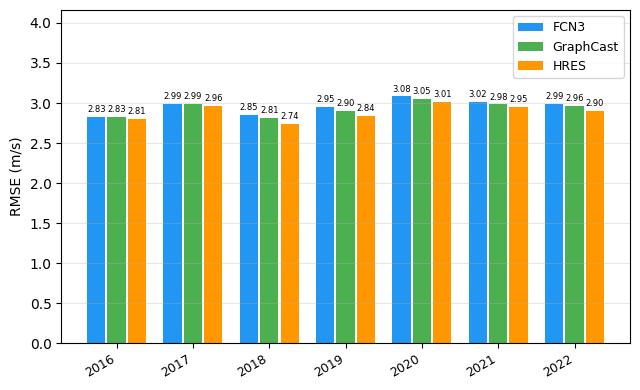

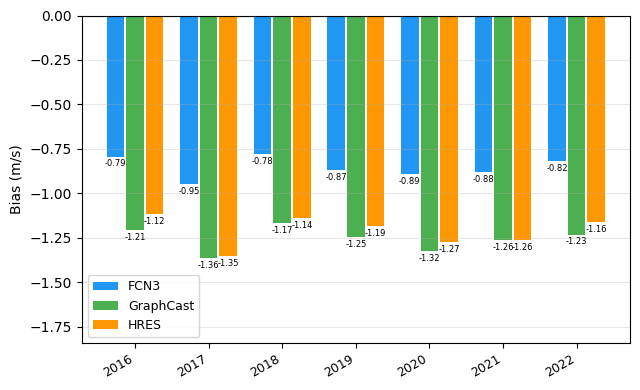

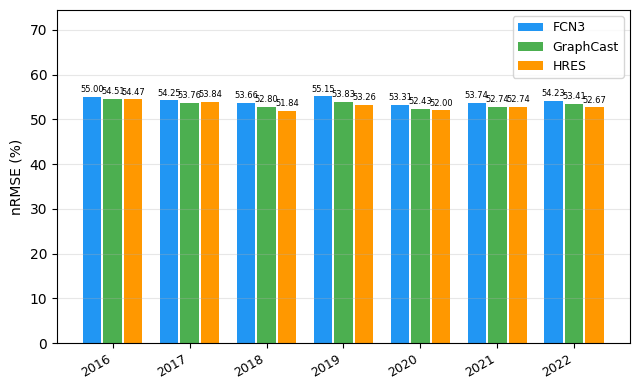

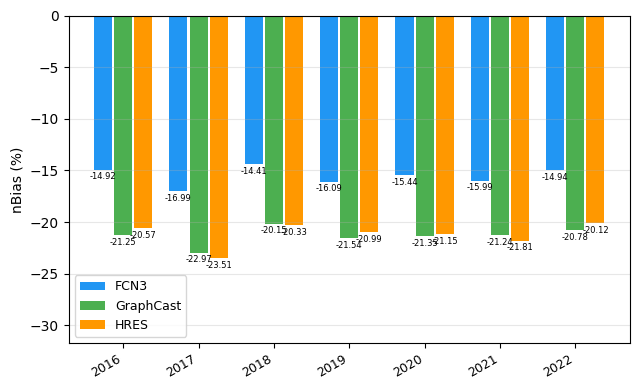

In [11]:
metrics_vs_obs_year = compute_group_metrics_by_station(master_df, 'forecast', 'obs', ['model', 'year', 'lead_h'])
year_metrics = [('RMSE', 'RMSE (m/s)'), ('Bias', 'Bias (m/s)'), ('nRMSE', 'nRMSE (%)'), ('nBias', 'nBias (%)')]

year_x = np.arange(len(YEARS))
n_models = len(MODEL_ORDER)
bar_w = 0.8 / n_models

for metric, ylabel in year_metrics:
    fig, ax = plt.subplots(figsize=(6.5, 4))
    for i, model in enumerate(MODEL_ORDER):
        by_year = (metrics_vs_obs_year[metrics_vs_obs_year['model'] == model]
                   .groupby('year')[metric].mean())
        vals = [by_year.get(yr, np.nan) for yr in YEARS]
        offset = (i - (n_models - 1) / 2) * bar_w
        bars = ax.bar(year_x + offset, vals, width=bar_w * 0.9, color=CLR[model], label=model)
        ax.bar_label(bars, fmt='%.2f', fontsize=6, padding=2)
    if metric == 'Bias':
        ax.axhline(0, color='k', lw=0.8, linestyle='-', alpha=0.4)
    ax.margins(y=0.35)
    ax.set_xticks(year_x); ax.set_xticklabels(YEARS, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'year_wise_analysis_{metric.lower()}.png', dpi=130, bbox_inches='tight')
    plt.show()

In [12]:
# 12.x Year-wise performance vs Station Obs, mean +/- std-across-stations format
# for all metrics (same convention as Section 7's std_by_model print block), averaged
# over all lead times +6h to +72h. std here is station-to-station spread, not a
# sampling CI (see station_bootstrap_rmse_diff in Section 7.x for CIs on differences).
ALL_METRICS = ['RMSE', 'nRMSE', 'Bias', 'nBias', 'Corr']

metrics_vs_obs_year_full = metrics_vs_obs_year.merge(
    add_station_std(master_df, 'forecast', 'obs', ['model', 'year', 'lead_h'], metrics=ALL_METRICS),
    on=['model', 'year', 'lead_h'], how='left')

# Collapse lead_h -> one row per (model, year): mean of the already station-averaged
# values, and mean of the already-computed per-lead_h station std (same convention as
# Section 7's std_by_model, which averages *_std across lead_h).
val_cols = ALL_METRICS
std_cols = [f'{m}_std' for m in ALL_METRICS]
by_year_std = (metrics_vs_obs_year_full.groupby(['model', 'year'])[val_cols + std_cols]
               .mean()
               .reset_index())

print('Year-wise performance vs Station Obs (mean +/- std-across-12-stations, '
      'averaged over all lead times +6h to +72h)')
print('=' * 100)
for yr in YEARS:
    print(f'\n{yr}:')
    for model in MODEL_ORDER:
        row = by_year_std[(by_year_std['model'] == model) & (by_year_std['year'] == yr)]
        if row.empty:
            print(f'  {model:10s}  no data')
            continue
        row = row.iloc[0]
        parts = [f'{m}={row[m]:.3f} \u00b1 {row[f"{m}_std"]:.3f}' for m in ALL_METRICS]
        print(f'  {model:10s}  ' + '   '.join(parts))


Year-wise performance vs Station Obs (mean +/- std-across-12-stations, averaged over all lead times +6h to +72h)

2016:
  FCN3        RMSE=2.829 ± 0.747   nRMSE=54.996 ± 14.781   Bias=-0.794 ± 1.089   nBias=-14.917 ± 20.468   Corr=0.630 ± 0.114
  GraphCast   RMSE=2.826 ± 0.911   nRMSE=54.514 ± 15.280   Bias=-1.206 ± 1.056   nBias=-21.254 ± 17.910   Corr=0.658 ± 0.116
  HRES        RMSE=2.805 ± 0.765   nRMSE=54.467 ± 14.874   Bias=-1.119 ± 0.929   nBias=-20.574 ± 17.489   Corr=0.654 ± 0.096

2017:
  FCN3        RMSE=2.992 ± 0.689   nRMSE=54.245 ± 14.621   Bias=-0.948 ± 1.067   nBias=-16.989 ± 19.438   Corr=0.671 ± 0.080
  GraphCast   RMSE=2.989 ± 0.861   nRMSE=53.758 ± 14.904   Bias=-1.365 ± 1.030   nBias=-22.965 ± 16.804   Corr=0.702 ± 0.088
  HRES        RMSE=2.960 ± 0.755   nRMSE=53.839 ± 15.997   Bias=-1.353 ± 0.865   nBias=-23.505 ± 15.298   Corr=0.700 ± 0.086

2018:
  FCN3        RMSE=2.847 ± 0.554   nRMSE=53.655 ± 14.150   Bias=-0.780 ± 0.980   nBias=-14.412 ± 19.669   Corr=0.640

## 13. High Wind-Speed Case Analysis

Builds a 4-way inner-merged dataset (FCN3 ∩ GraphCast ∩ HRES ∩ Obs, matched on
station/valid_time/lead_h) so all three models are scored on exactly the same events, then looks
at performance conditional on observed wind speed (threshold: 10.8 m/s, Beaufort
9-12 near-gale/gale), with a specific look at the coastal lighthouse stations.

In [13]:
FORCE_RECOMPUTE_MERGED = False

if CSV_HW_MERGED.exists() and not FORCE_RECOMPUTE_MERGED:
    merged_all = pd.read_csv(CSV_HW_MERGED, parse_dates=['valid_time'])
    print(f'Loaded from cache: {CSV_HW_MERGED.name}  ({len(merged_all):,} rows)')
else:
    parts = []
    for year in YEARS:
        print(f'\nYear {year}')
        obs_df = load_obs(year)
        fc_df  = load_fcn3(year)
        gc_df  = load_graphcast(year)
        hr_df  = load_hres(year)
        dfs = [obs_df, fc_df, gc_df, hr_df]
        for df in dfs:
            if not df.empty and 'valid_time' in df.columns:
                df['valid_time'] = df['valid_time'].astype('datetime64[us]')
        if any(df.empty for df in dfs):
            print('  Missing data for one or more sources — skipping year.')
            continue
        m = (fc_df.merge(gc_df, on=['station', 'valid_time', 'lead_h'], how='inner')
                   .merge(hr_df, on=['station', 'valid_time', 'lead_h'], how='inner')
                   .merge(obs_df, on=['station', 'valid_time'], how='inner'))
        if m.empty:
            print('  No overlapping data — skipping year.')
            continue
        m['year'] = year
        parts.append(m)
        print(f'  Merged rows: {len(m):,}')

    merged_all = pd.concat(parts, ignore_index=True)
    merged_all.to_csv(CSV_HW_MERGED, index=False)
    print(f'\nSaved: {CSV_HW_MERGED}  ({len(merged_all):,} rows)')

merged_all.head()

Loaded from cache: merged_fcn3_graphcast_hres_obs_all_years_72h_interp.csv  (366,585 rows)


,station,valid_time,lead_h,fcn3_wind,graphcast_wind,hres_wind,obs_wind,year
0,SN85380,2016-01-01 06:00:00,6,9.337983,9.725429,9.247075,4.8,2016
1,SN85380,2016-01-02 06:00:00,6,6.603169,6.551483,6.265541,3.1,2016
2,SN85380,2016-01-03 06:00:00,6,3.772298,4.225825,3.259856,7.2,2016
3,SN85380,2016-01-04 06:00:00,6,8.106786,9.566396,7.744251,8.9,2016
4,SN85380,2016-01-05 06:00:00,6,6.008563,5.984540,5.847421,7.0,2016


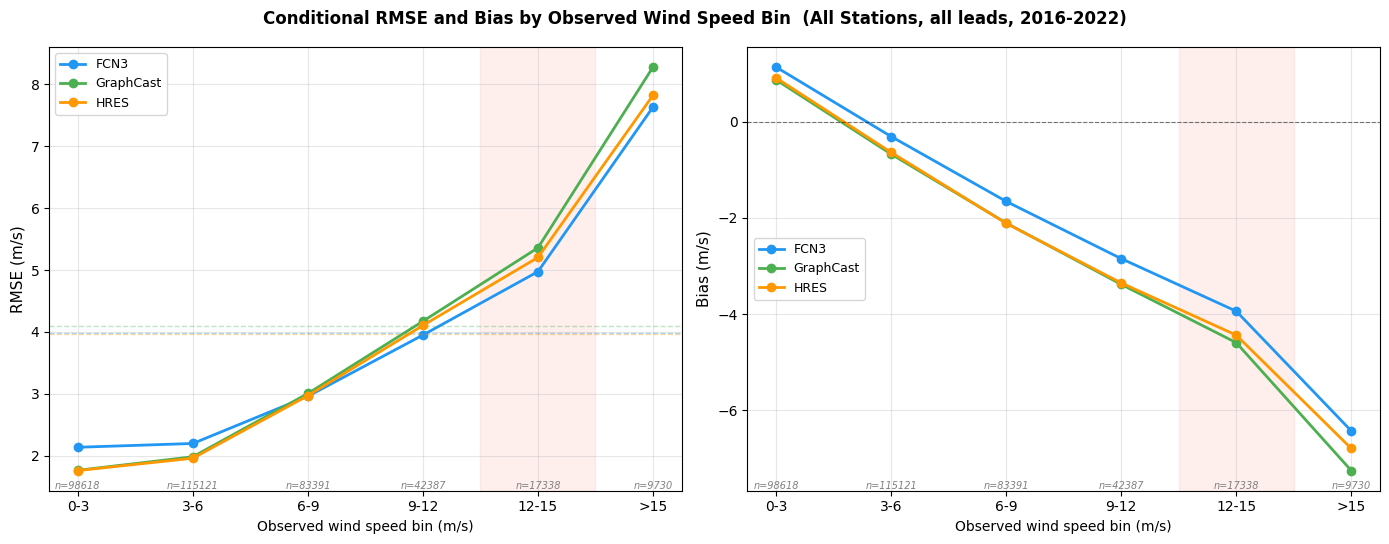

In [14]:
BINS   = [0, 3, 6, 9, 12, 15, 100]
LABELS = ['0-3', '3-6', '6-9', '9-12', '12-15', '>15']
MODEL_COLS = [('fcn3_wind', 'FCN3'), ('graphcast_wind', 'GraphCast'), ('hres_wind', 'HRES')]

merged_all['obs_bin'] = pd.cut(merged_all['obs_wind'], bins=BINS, labels=LABELS, right=False)
bin_counts = merged_all['obs_bin'].value_counts().reindex(LABELS, fill_value=0)

fig, (ax_rmse, ax_bias) = plt.subplots(1, 2, figsize=(14, 5.5))
x = np.arange(len(LABELS))
for wind_col, model in MODEL_COLS:
    rmse_vals, bias_vals = [], []
    for lbl in LABELS:
        grp = merged_all[merged_all['obs_bin'] == lbl]
        if len(grp) < 2:
            rmse_vals.append(np.nan); bias_vals.append(np.nan); continue
        err = grp[wind_col] - grp['obs_wind']
        rmse_vals.append(float(np.sqrt((err ** 2).mean())))
        bias_vals.append(float(err.mean()))
    ax_rmse.plot(x, rmse_vals, marker='o', lw=2, ms=6, color=CLR[model], label=model)
    ax_rmse.axhline(np.nanmean(rmse_vals), color=CLR[model], lw=1, linestyle='--', alpha=0.35)
    ax_bias.plot(x, bias_vals, marker='o', lw=2, ms=6, color=CLR[model], label=model)

ax_bias.axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
for ax, ylabel in [(ax_rmse, 'RMSE (m/s)'), (ax_bias, 'Bias (m/s)')]:
    ax.set_xticks(x); ax.set_xticklabels(LABELS, fontsize=10)
    ax.set_xlabel('Observed wind speed bin (m/s)', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.axvspan(3.5, 4.5, color='salmon', alpha=0.12, zorder=0)
    ax.grid(alpha=0.3); ax.legend(fontsize=9)
    for i, lbl in enumerate(LABELS):
        ax.text(i, ax.get_ylim()[0], f'n={bin_counts[lbl]}', ha='center', va='bottom',
                fontsize=7, color='gray', style='italic')

fig.suptitle('Conditional RMSE and Bias by Observed Wind Speed Bin  (All Stations, all leads, 2016-2022)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'hw_conditional_rmse_bias.png', dpi=130, bbox_inches='tight')
plt.show()

In [15]:
hw = merged_all[merged_all['obs_wind'] >= HIGH_WIND_THR]
print(f'High-wind events: obs >= {HIGH_WIND_THR} m/s   N={len(hw):,}  '
      f'({len(hw) / len(merged_all) * 100:.2f}% of all records)')

rows = []
for wind_col, model in MODEL_COLS:
    for sid in STATION_ORDER:
        sub = hw[hw['station'] == sid]
        if len(sub) == 0:
            continue
        err = sub[wind_col] - sub['obs_wind']
        rmse = float(np.sqrt((err ** 2).mean()))
        bias = float(err.mean())
        mean_obs = float(sub['obs_wind'].mean())
        rows.append({'Model': model, 'Station': sid, 'N': len(sub),
                     'RMSE': round(rmse, 3),
                     'MAE':  round(float(err.abs().mean()), 3),
                     'Bias': round(bias, 3),
                     'nRMSE': round(rmse / mean_obs * 100, 2) if mean_obs else np.nan,
                     'nBias': round(bias / mean_obs * 100, 2) if mean_obs else np.nan})
hw_table = pd.DataFrame(rows)

# 'All Stations' = mean across the 12 per-station rows above (station-level evaluation,
# each station weighted equally), not a fresh pooled computation on `hw` directly.
_all_stations_rows = []
for model in MODEL_ORDER:
    sub = hw_table[hw_table['Model'] == model]
    _all_stations_rows.append({
        'Model': model, 'Station': 'All Stations', 'N': int(sub['N'].sum()),
        'RMSE': sub['RMSE'].mean(), 'MAE': sub['MAE'].mean(), 'Bias': sub['Bias'].mean(),
        'nRMSE': sub['nRMSE'].mean(), 'nBias': sub['nBias'].mean(),
    })
hw_table = pd.concat([hw_table, pd.DataFrame(_all_stations_rows)], ignore_index=True)

# Station-to-station std (across the 12 per-station rows above), not a sampling CI
_hw_std = (hw_table[hw_table['Station'].isin(STATION_ORDER)]
           .groupby('Model')[['RMSE', 'MAE', 'Bias', 'nRMSE', 'nBias']].std()
           .rename(columns=lambda c: f'{c}_std_across_stations'))
hw_all_stations = (hw_table[hw_table['Station'] == 'All Stations']
                    .merge(_hw_std.reset_index(), on='Model', how='left'))
display(hw_all_stations.reset_index(drop=True))

print(f'\nCoastal (Fyr) stations only: {[STATIONS_BY_ID[s]["name"] for s in COASTAL_STATIONS]}')
display(hw_table[hw_table['Station'].isin(COASTAL_STATIONS)]
        .assign(Station=lambda d: d['Station'].map(lambda s: STATIONS_BY_ID[s]['name']))
        .sort_values(['Model', 'Station']).reset_index(drop=True))

High-wind events: obs >= 10.8 m/s   N=40,247  (10.98% of all records)


,Model,Station,N,RMSE,MAE,Bias,nRMSE,nBias,RMSE_std_across_stations,MAE_std_across_stations,Bias_std_across_stations,nRMSE_std_across_stations,nBias_std_across_stations
0,FCN3,All Stations,40247,5.766250,5.188583,-4.979000,43.424167,-37.578333,1.963761,2.143690,2.388272,15.447152,18.751548
1,GraphCast,All Stations,40247,6.009333,5.501583,-5.428417,45.140833,-40.823333,1.931583,2.059054,2.160661,14.747504,16.668321
2,HRES,All Stations,40247,6.047833,5.548833,-5.496083,45.587500,-41.508333,1.875721,2.014089,2.072734,14.973020,16.571389



Coastal (Fyr) stations only: ['Hekkingen Fyr', 'Torsvåg Fyr', 'Skrova Fyr', 'Fruholmen Fyr', 'Slettnes Fyr']


,Model,Station,N,RMSE,MAE,Bias,nRMSE,nBias
0,FCN3,Fruholmen Fyr,7467,3.824,3.043,-2.752,27.40,-19.72
1,FCN3,Hekkingen Fyr,3563,5.962,5.303,-5.222,43.10,-37.75
2,FCN3,Skrova Fyr,3611,4.308,3.579,-3.345,32.31,-25.08
3,FCN3,Slettnes Fyr,4912,4.018,3.350,-3.244,29.75,-24.02
4,FCN3,Torsvåg Fyr,3283,3.604,2.724,-1.730,27.11,-13.02
5,GraphCast,Fruholmen Fyr,7467,4.016,3.382,-3.303,28.78,-23.67
6,GraphCast,Hekkingen Fyr,3563,6.385,5.836,-5.821,46.16,-42.08
7,GraphCast,Skrova Fyr,3611,4.674,4.022,-3.936,35.05,-29.51
8,GraphCast,Slettnes Fyr,4912,4.744,4.210,-4.201,35.13,-31.11
9,GraphCast,Torsvåg Fyr,3283,4.233,3.375,-3.215,31.85,-24.19


### 13.x High-Wind Performance by Model and Lead Time

The station/coastal breakdown above summarizes high-wind performance averaged across all lead
times. This mirrors Section 7's [model, lead_h] comparison exactly, but restricted to the
high-wind subset (`hw`), so the three models can be compared the same way (table, ranking,
lead-time curves) under high-wind conditions specifically.

In [16]:
# Reshape the high-wind subset to long format (model, forecast, obs) and reuse
# compute_group_metrics exactly as in Section 7, grouped by [model, lead_h]
hw_long = pd.concat([
    hw[['station', 'valid_time', 'lead_h', wind_col, 'obs_wind']]
        .rename(columns={wind_col: 'forecast', 'obs_wind': 'obs'})
        .assign(model=model)
    for wind_col, model in MODEL_COLS
], ignore_index=True)

metrics_hw_vs_obs = compute_group_metrics_by_station(hw_long, 'forecast', 'obs', ['model', 'lead_h'])
metrics_hw_vs_obs = metrics_hw_vs_obs.merge(
    add_station_std(hw_long, 'forecast', 'obs', ['model', 'lead_h'],
                     metrics=('RMSE', 'nRMSE', 'Bias', 'nBias', 'Corr')),
    on=['model', 'lead_h'], how='left')
metrics_hw_vs_obs = metrics_hw_vs_obs.set_index(['model', 'lead_h']).reindex(
    pd.MultiIndex.from_product([MODEL_ORDER, LEAD_HOURS], names=['model', 'lead_h'])
).reset_index()

print(f'High-wind (obs >= {HIGH_WIND_THR} m/s) performance vs Station Obs — grouped by [model, lead_h]')
display(metrics_hw_vs_obs.round(3))

High-wind (obs >= 10.8 m/s) performance vs Station Obs — grouped by [model, lead_h]


,model,lead_h,N,RMSE,MAE,Bias,nRMSE,nBias,Corr,RMSE_std,nRMSE_std,Bias_std,nBias_std,Corr_std
0,FCN3,6,3361.0,5.501,5.044,-4.863,41.544,-36.789,0.535,2.188,17.122,2.536,19.850,0.129
1,FCN3,12,3454.0,5.298,4.807,-4.606,39.896,-34.753,0.529,2.092,16.366,2.449,19.159,0.143
2,FCN3,18,3383.0,5.392,4.886,-4.671,40.520,-35.185,0.534,2.096,16.278,2.459,19.138,0.123
3,FCN3,24,3282.0,5.571,5.035,-4.849,41.874,-36.522,0.488,2.146,16.706,2.508,19.538,0.124
4,FCN3,30,3336.0,5.560,5.062,-4.830,42.005,-36.559,0.508,2.053,16.081,2.484,19.442,0.139
5,FCN3,36,3432.0,5.483,4.941,-4.726,41.273,-35.643,0.488,2.022,15.798,2.427,18.993,0.112
6,FCN3,42,3369.0,5.743,5.197,-4.992,43.151,-37.603,0.489,1.968,15.468,2.372,18.634,0.112
7,FCN3,48,3269.0,5.969,5.399,-5.213,44.857,-39.263,0.443,2.037,15.990,2.438,19.131,0.127
8,FCN3,54,3327.0,6.001,5.424,-5.215,45.336,-39.481,0.423,1.977,15.607,2.425,19.084,0.118
9,FCN3,60,3420.0,6.072,5.407,-5.155,45.755,-38.937,0.355,1.848,14.664,2.340,18.496,0.139


In [17]:
# Mean +/- std-across-stations (averaged over lead time) alongside each ranked value,
# matching the Section 7 ranking format. std here is station-to-station spread, not a
# sampling CI on the ranked value itself.
std_by_model_hw = metrics_hw_vs_obs.groupby('model')[['RMSE_std', 'nRMSE_std', 'Bias_std', 'nBias_std', 'Corr_std']].mean()
n_by_model_hw = metrics_hw_vs_obs.groupby('model')['N'].sum()  # total matched samples across all lead times

print('High-wind model ranking (lower is better for RMSE/nRMSE; Corr ranked higher-is-better)')
print('=' * 60)
for metric, ascending in [('RMSE', True), ('nRMSE', True), ('Bias', True), ('nBias', True), ('Corr', False)]:
    ranking = rank_models_by_metric(metrics_hw_vs_obs, metric, ascending)
    print(f'\nRanked by {metric}:')
    for i, (model, val) in enumerate(ranking.items(), 1):
        std_val = std_by_model_hw.loc[model, f'{metric}_std']
        n_val = int(n_by_model_hw.loc[model])
        print(f'  {i}. {model:10s}  {metric}={val:.3f} ± {std_val:.3f} (across stations)  N={n_val:,}')

High-wind model ranking (lower is better for RMSE/nRMSE; Corr ranked higher-is-better)

Ranked by RMSE:
  1. FCN3        RMSE=5.760 ± 1.996 (across stations)  N=40,247
  2. GraphCast   RMSE=6.003 ± 1.959 (across stations)  N=40,247
  3. HRES        RMSE=6.045 ± 1.899 (across stations)  N=40,247

Ranked by nRMSE:
  1. FCN3        nRMSE=43.358 ± 15.642 (across stations)  N=40,247
  2. GraphCast   nRMSE=45.080 ± 14.921 (across stations)  N=40,247
  3. HRES        nRMSE=45.547 ± 15.120 (across stations)  N=40,247

Ranked by Bias:
  1. HRES        Bias=-5.507 ± 2.090 (across stations)  N=40,247
  2. GraphCast   Bias=-5.438 ± 2.179 (across stations)  N=40,247
  3. FCN3        Bias=-4.991 ± 2.407 (across stations)  N=40,247

Ranked by nBias:
  1. HRES        nBias=-41.574 ± 16.679 (across stations)  N=40,247
  2. GraphCast   nBias=-40.882 ± 16.783 (across stations)  N=40,247
  3. FCN3        nBias=-37.649 ± 18.861 (across stations)  N=40,247

Ranked by Corr:
  1. GraphCast   Corr=0.488 ± 0.12

In [18]:
# 13.x.z Statistical significance of model differences, high-wind subset, all metrics
# Answers the reviewer question: "are different models statistically significant in
# the high-wind scenario?" -- for RMSE, nRMSE, Bias, nBias, and Corr, the same metrics
# reported for the high-wind subset in Section 13.x above (metrics_hw_vs_obs), not just
# ETS (which already has a significance test in Section 13.y.4/13.z.2b).
#
# This uses a STATION-AVERAGE, not a pooled, construction: for each (model, station),
# the metric is computed per lead_h first (compute_group_metrics on hw_long grouped by
# ['model', 'station', 'lead_h']), then averaged across the 12 lead times -- each lead
# time weighted equally, consistent with how the rest of the notebook aggregates lead_h
# (e.g. Section 7's overall ranking = mean across lead_h of the already
# station-averaged metric; see compute_group_metrics_by_station). This differs from
# pooling raw high-wind residuals across all lead times into one RMSE/Bias/etc. per
# station, which would instead weight each lead time by how many high-wind events it
# happened to contain. The resulting one-number-per-(model, station) table is then
# cluster-bootstrapped over the 12 stations exactly as in Section 7.x.
hw_station_lead = compute_group_metrics(hw_long, 'forecast', 'obs', ['model', 'station', 'lead_h'])
hw_station_avg = hw_station_lead.groupby(['model', 'station'])[ALL_METRICS].mean().reset_index()


def station_bootstrap_diff_avg_lead(station_level, metric, models=MODEL_ORDER, n_boot=N_BOOT, seed=5):
    """Cluster (station-level) bootstrap for pairwise differences of a metric that has
    already been averaged across lead_h per (model, station) -- same resampling
    mechanics as station_bootstrap_rmse_diff (Section 7.x), applied to a precomputed
    table instead of recomputing a pooled metric from raw rows."""
    rng = np.random.default_rng(seed)
    rows = []
    for m1, m2 in combinations(models, 2):
        s1 = station_level[station_level['model'] == m1].set_index('station')[metric].dropna()
        s2 = station_level[station_level['model'] == m2].set_index('station')[metric].dropna()
        common = s1.index.intersection(s2.index)
        n = len(common)
        if n < 1:
            mean_diff = ci_low = ci_high = p_value = np.nan
        else:
            x, y = s1.loc[common].to_numpy(), s2.loc[common].to_numpy()
            mean_diff = float(np.mean(x - y))
            idx = rng.integers(0, n, size=(n_boot, n))
            boot_diffs = (x[idx] - y[idx]).mean(axis=1)
            ci_low, ci_high = (float(v) for v in np.percentile(boot_diffs, [2.5, 97.5]))
            p_value = float(min(1.0, 2 * min((boot_diffs <= 0).mean(), (boot_diffs >= 0).mean())))
        rows.append({'model_a': m1, 'model_b': m2, 'n_stations': n,
                     'mean_diff': mean_diff, 'ci_low': ci_low, 'ci_high': ci_high,
                     'p_value': p_value,
                     'significant_0.05': bool(pd.notna(ci_low) and (ci_low > 0 or ci_high < 0))})
    return pd.DataFrame(rows)


HW_SIG_SEEDS = {'RMSE': 20, 'nRMSE': 21, 'Bias': 22, 'nBias': 23, 'Corr': 24}

sig_hw_by_metric = {}
for metric in ALL_METRICS:
    print(f'High-wind (obs >= {HIGH_WIND_THR} m/s) pairwise significance of {metric} differences')
    print(f'(station-average over lead_h; station-level cluster bootstrap, n_boot={N_BOOT:,})')
    sig = station_bootstrap_diff_avg_lead(hw_station_avg, metric, seed=HW_SIG_SEEDS[metric])
    sig_hw_by_metric[metric] = sig
    display(sig.round(4))
    print()


High-wind (obs >= 10.8 m/s) pairwise significance of RMSE differences
(station-average over lead_h; station-level cluster bootstrap, n_boot=10,000)


,model_a,model_b,n_stations,mean_diff,ci_low,ci_high,p_value,significant_0.05
0,FCN3,GraphCast,12,-0.2436,-0.5074,0.0339,0.0824,False
1,FCN3,HRES,12,-0.2851,-0.6646,-0.0005,0.0496,True
2,GraphCast,HRES,12,-0.0415,-0.4437,0.3366,0.8330,False



High-wind (obs >= 10.8 m/s) pairwise significance of nRMSE differences
(station-average over lead_h; station-level cluster bootstrap, n_boot=10,000)


,model_a,model_b,n_stations,mean_diff,ci_low,ci_high,p_value,significant_0.05
0,FCN3,GraphCast,12,-1.7221,-3.5798,0.3152,0.1016,False
1,FCN3,HRES,12,-2.1895,-5.0073,-0.0233,0.0478,True
2,GraphCast,HRES,12,-0.4674,-3.3891,2.2920,0.7612,False



High-wind (obs >= 10.8 m/s) pairwise significance of Bias differences
(station-average over lead_h; station-level cluster bootstrap, n_boot=10,000)


,model_a,model_b,n_stations,mean_diff,ci_low,ci_high,p_value,significant_0.05
0,FCN3,GraphCast,12,0.4476,0.1080,0.7876,0.0108,True
1,FCN3,HRES,12,0.5162,0.1031,1.0845,0.0064,True
2,GraphCast,HRES,12,0.0686,-0.3710,0.5359,0.7858,False



High-wind (obs >= 10.8 m/s) pairwise significance of nBias differences
(station-average over lead_h; station-level cluster bootstrap, n_boot=10,000)


,model_a,model_b,n_stations,mean_diff,ci_low,ci_high,p_value,significant_0.05
0,FCN3,GraphCast,12,3.2329,0.6178,5.7375,0.0164,True
1,FCN3,HRES,12,3.9251,0.7284,8.2831,0.0066,True
2,GraphCast,HRES,12,0.6922,-2.5980,4.1384,0.7118,False



High-wind (obs >= 10.8 m/s) pairwise significance of Corr differences
(station-average over lead_h; station-level cluster bootstrap, n_boot=10,000)


,model_a,model_b,n_stations,mean_diff,ci_low,ci_high,p_value,significant_0.05
0,FCN3,GraphCast,12,-0.0240,-0.0405,-0.0073,0.0062,True
1,FCN3,HRES,12,-0.0169,-0.0544,0.0404,0.4882,False
2,GraphCast,HRES,12,0.0071,-0.0310,0.0572,0.8252,False


### 13.x.zz Robustness Check: Exact Sign-Flip Test (Addresses "Only 12 Clusters" Concern)

The cluster bootstrap above resamples the 12 stations with replacement -- clustering *by
station* already handles temporal autocorrelation within a station's series (a resample draws
a whole station intact, never individual timesteps) and shared-weather-event correlation across
stations (station-hours are never treated as independent). But with only 12 clusters, the
bootstrap's usual large-N justification is weak, and 10,000 resamples does not change that --
it is still only reshuffling 12 units.

This runs an **exact sign-flip (randomization) test** instead: with 12 paired per-station
differences, there are exactly 2^12 = 4,096 possible +/- sign assignments, small enough to
enumerate completely -- no Monte Carlo approximation anywhere. The p-value is the fraction of
those 4,096 enumerated sign patterns whose resulting mean absolute difference is >= the observed
one. Critically, this test's validity rests only on sign-exchangeability under the null (no
systematic model preference), not on independence across stations or on any large-n asymptotic
-- so it is robust to exactly the cross-station shared-weather-event correlation the bootstrap
cannot fully rule out. Applied to the two headline comparisons (overall RMSE vs Obs, and the
high-wind Bias result from Section 13), it corroborates the bootstrap's conclusions using a
method with no small-cluster caveat at all.


In [19]:
# 13.x.zz Exact sign-flip test: enumerate all 2^12 sign patterns for the 12 per-station
# paired differences -- exact, not a resampling approximation, and valid regardless of
# cross-station correlation (only requires sign-exchangeability under H0).
from itertools import product as _product

def exact_signflip_test(d):
    """Exact two-sided sign-flip test on paired per-cluster differences `d` (one value
    per station). Enumerates all 2^n sign patterns -- exact for small n (here n=12,
    2^12=4096), valid under sign-exchangeability alone."""
    n = len(d)
    d = np.asarray(d)
    obs = d.mean()
    all_signs = np.array(list(_product([1, -1], repeat=n)))
    null_dist = (all_signs * d).mean(axis=1)
    p_value = float((np.abs(null_dist) >= np.abs(obs) - 1e-12).mean())
    return obs, p_value, n


print('=== Exact sign-flip test: overall RMSE differences vs Station Obs '
      '(all lead times pooled per station) ===')
station_level_rmse = compute_group_metrics(master_df, 'forecast', 'obs', ['model', 'station'])
signflip_rows = []
for m1, m2 in combinations(MODEL_ORDER, 2):
    s1 = station_level_rmse[station_level_rmse['model'] == m1].set_index('station')['RMSE']
    s2 = station_level_rmse[station_level_rmse['model'] == m2].set_index('station')['RMSE']
    common = s1.index.intersection(s2.index)
    d = (s1.loc[common] - s2.loc[common]).to_numpy()
    obs, p, n = exact_signflip_test(d)
    print(f'  {m1} - {m2}: mean_diff={obs:.4f}  exact_p={p:.4f}  (n={n} stations, {2**n} sign patterns enumerated)')
    signflip_rows.append({'comparison': f'{m1} - {m2}', 'metric': 'RMSE vs Obs (overall)',
                           'mean_diff': obs, 'exact_p_value': p})

print()
print('=== Exact sign-flip test: high-wind Bias differences '
      f'(obs >= {HIGH_WIND_THR} m/s, station-average over lead_h) ===')
hw_station_lead_bias = compute_group_metrics(hw_long, 'forecast', 'obs', ['model', 'station', 'lead_h'])
hw_station_avg_bias = hw_station_lead_bias.groupby(['model', 'station'])['Bias'].mean().reset_index()
for m1, m2 in combinations(MODEL_ORDER, 2):
    s1 = hw_station_avg_bias[hw_station_avg_bias['model'] == m1].set_index('station')['Bias']
    s2 = hw_station_avg_bias[hw_station_avg_bias['model'] == m2].set_index('station')['Bias']
    common = s1.index.intersection(s2.index)
    d = (s1.loc[common] - s2.loc[common]).to_numpy()
    obs, p, n = exact_signflip_test(d)
    print(f'  {m1} - {m2}: mean_diff={obs:.4f}  exact_p={p:.4f}  (n={n} stations, {2**n} sign patterns enumerated)')
    signflip_rows.append({'comparison': f'{m1} - {m2}', 'metric': 'Bias, high-wind subset',
                           'mean_diff': obs, 'exact_p_value': p})

signflip_summary = pd.DataFrame(signflip_rows)
print('\nSummary (compare exact_p_value here against the bootstrap p_value in Sections 7.x/13.x.z):')
display(signflip_summary.round(4))


=== Exact sign-flip test: overall RMSE differences vs Station Obs (all lead times pooled per station) ===
  FCN3 - GraphCast: mean_diff=0.0287  exact_p=0.7046  (n=12 stations, 4096 sign patterns enumerated)
  FCN3 - HRES: mean_diff=0.0730  exact_p=0.0610  (n=12 stations, 4096 sign patterns enumerated)
  GraphCast - HRES: mean_diff=0.0443  exact_p=0.5005  (n=12 stations, 4096 sign patterns enumerated)

=== Exact sign-flip test: high-wind Bias differences (obs >= 10.8 m/s, station-average over lead_h) ===
  FCN3 - GraphCast: mean_diff=0.4476  exact_p=0.0420  (n=12 stations, 4096 sign patterns enumerated)
  FCN3 - HRES: mean_diff=0.5162  exact_p=0.0312  (n=12 stations, 4096 sign patterns enumerated)
  GraphCast - HRES: mean_diff=0.0686  exact_p=0.7803  (n=12 stations, 4096 sign patterns enumerated)

Summary (compare exact_p_value here against the bootstrap p_value in Sections 7.x/13.x.z):


,comparison,metric,mean_diff,exact_p_value
0,FCN3 - GraphCast,RMSE vs Obs (overall),0.0287,0.7046
1,FCN3 - HRES,RMSE vs Obs (overall),0.0730,0.0610
2,GraphCast - HRES,RMSE vs Obs (overall),0.0443,0.5005
3,FCN3 - GraphCast,"Bias, high-wind subset",0.4476,0.0420
4,FCN3 - HRES,"Bias, high-wind subset",0.5162,0.0312
5,GraphCast - HRES,"Bias, high-wind subset",0.0686,0.7803


## 16. Anomaly Correlation Coefficient (ACC)

All metrics used so far (RMSE, MAE, Bias, Corr) compare raw wind-speed values. That has a
subtle problem: wind speed has a strong, easily-predictable seasonal and diurnal cycle (e.g.
winter is windier than summer at most of these stations), so a plain correlation between
forecast and obs can look good largely because every model gets the *climatology* right, not
because it captures actually unusual, hard-to-predict weather.

The **Anomaly Correlation Coefficient (ACC)** removes this by first subtracting a climatological
reference from both forecast and observation, then correlating what's left over — the
*anomalies*. This is the standard skill score used in operational NWP verification, and the one
GraphCast, FourCastNet 3, and the WeatherBench2 benchmark all report — precisely because it
isolates a model's ability to capture unusual/anomalous conditions rather than just the
predictable seasonal signal.

**Climatology.** Two lines are evaluated, each with its own climatology source:

- **vs Station Obs**: no long-term reference exists for these 12 stations beyond our own
  2016–2022 observations, so the climatology `C(station, day-of-year)` is computed directly from
  them: for each station and each day-of-year (1–366), a **61-day sliding window** centred on
  that day (±30 days, wrapping across the year boundary) is averaged across all years, with
  weights decaying linearly from 1 at the window centre to 0 at the edges. This follows the same
  smoothing convention as the ECMWF/WeatherBench2 climatologies below, replacing the coarser
  per-calendar-month bins used in an earlier version of this analysis (which produced visible
  jumps in the climatology across month boundaries). The main limitation of this line is the
  short (7-year) baseline period, not the day-of-year resolution — noted here as a caveat rather
  than corrected, since a longer station record does not exist.
- **vs ERA5**: uses the official WeatherBench2 ERA5 climatology (`10m_wind_speed`, `1990–2017`
  baseline, day-of-year × 6-hourly, pre-smoothed by WB2 with the same 61-day linear window) via
  `earth2studio.data.WB2Climatology`. This is the same climatology WeatherBench2/GraphCast-style
  evaluations use. Because the compute nodes used to run this notebook cannot reach Google Cloud
  Storage (verified directly — the request hangs rather than failing), the climatology was
  extracted once from the login node, bilinearly interpolated to the 12 station coordinates, and
  cached locally as `wb2_climatology_station_10m_wind_speed.csv`; the notebook itself only reads
  that local file and never talks to GCS.

**ACC formula.** Given anomalies `f' = forecast − C` and `o' = obs (or ERA5) − C`, the score used
here is the **WeatherBench2** formula (Rasp et al. 2024, JAMES, doi:10.1029/2023MS004019 — the
same equation implemented in the released `weatherbench2.metrics.ACC`), with no further
de-meaning of the anomalies:

```
ACC = Σ(f'·o') / sqrt( Σ(f'²) · Σ(o'²) )
```

**Correction:** an earlier version of this notebook additionally subtracted each anomaly
series' own mean within the (model, station, lead_h) group before correlating (`f'' = f' −
mean(f')`, same for `o'`), which is algebraically the Pearson correlation coefficient of `f'`
and `o'`. That is a real, commonly used definition too — it is what `earth2studio.statistics.acc`
(vendored in this repo) implements, citing the classic ECMWF Standard Verification System
convention — but it is **not** the WeatherBench2 formula, and the two disagree whenever a
model's anomaly has a non-zero mean within a group (i.e. whenever there is a systematic
forecast bias): the centered/Pearson version is blind to that bias, while the WeatherBench2
formula is not. Since this analysis explicitly aims to be comparable with the ACC numbers
GraphCast/FourCastNet3/WeatherBench2 publish, and since RMSE/Bias/nBias already characterize
bias separately, the WeatherBench2 (uncentered) formula is used throughout.

**Interpretation** (range −1 to +1):
- **+1** — forecast anomalies perfectly track observed anomalies
- **0** — no skill beyond climatology (the forecast's deviations from the seasonal mean carry
  no information about the observed deviations)
- **negative** — forecast anomalies point the *wrong* way relative to what actually happened


In [20]:
# 16.1 Station-obs climatology: day-of-year, 61-day sliding window (ECMWF/WeatherBench2
# smoothing convention), then Anomaly Correlation Coefficient (ACC) vs Station Obs using
# the WeatherBench2 formula (see Section 16 markdown above for the centered-vs-uncentered
# correction).
HALF_WINDOW = 30  # +/-30 days => 61-day window, weights decay linearly to 0 at the edges

climo_source = (master_df[['station', 'valid_time', 'obs']]
                 .dropna(subset=['obs'])
                 .drop_duplicates(subset=['station', 'valid_time']))
climo_source['doy'] = climo_source['valid_time'].dt.dayofyear


def compute_doy_climatology(df, value_col, half_window=HALF_WINDOW):
    """Day-of-year climatology with a circular (year-wrapping), linear-decay window,
    matching the ECMWF/WeatherBench2 climatology smoothing convention."""
    rows = []
    for station, g in df.groupby('station'):
        doy = g['doy'].to_numpy()
        vals = g[value_col].to_numpy()
        for target in range(1, 367):
            diff = np.abs(doy - target)
            circ_diff = np.minimum(diff, 366 - diff)
            mask = circ_diff <= half_window
            if not mask.any():
                continue
            w = 1 - circ_diff[mask] / (half_window + 1)
            rows.append({'station': station, 'doy': target,
                         'climatology': float(np.average(vals[mask], weights=w))})
    return pd.DataFrame(rows)


station_doy_climatology = compute_doy_climatology(climo_source, 'obs')

acc_df = master_df.dropna(subset=['forecast', 'obs']).copy()
acc_df['doy'] = acc_df['valid_time'].dt.dayofyear
acc_df = acc_df.merge(station_doy_climatology, on=['station', 'doy'], how='left')
acc_df['fcst_anom'] = acc_df['forecast'] - acc_df['climatology']
acc_df['obs_anom']  = acc_df['obs'] - acc_df['climatology']


def compute_group_acc(df, group_cols, fcst_col='fcst_anom', ref_col='obs_anom'):
    """Grouped Anomaly Correlation Coefficient, WeatherBench2 formula (Rasp et al. 2024,
    JAMES -- https://doi.org/10.1029/2023MS004019, Eq. for ACC; matches the released
    weatherbench2.metrics.ACC source), which is what GraphCast/FourCastNet3-style papers
    actually report: anomalies are f' = forecast - climatology and o' = obs - climatology,
    with NO further de-meaning before correlating --

        ACC = sum(f' * o') / sqrt( sum(f'^2) * sum(o'^2) )

    CORRECTION: an earlier version of this cell additionally subtracted each anomaly
    series' own mean within the group (fa = f' - mean(f'), same for o') before applying
    this formula. That extra step is algebraically the Pearson correlation of f' and o',
    and matches a DIFFERENT reference implementation -- earth2studio.statistics.acc,
    vendored in this repo, which follows the classic ECMWF Standard Verification System
    convention (a domain-mean-removed spatial pattern correlation) -- but it is NOT the
    WeatherBench2 formula, and it silently discards the effect of a systematic forecast
    bias on the anomaly correlation (a model with a large, uncorrected mean bias in its
    anomalies would score the same ACC here as one with no bias, as long as the pattern
    tracks equally well). Since RMSE/Bias/nBias already characterize bias separately, and
    the two "official" definitions genuinely disagree, this notebook uses the WeatherBench2
    (uncentered) formula because that is the one whose published numbers this analysis is
    meant to be comparable with -- not because the centered/earth2studio version is wrong.
    """
    def _agg(g):
        s = g.dropna(subset=[fcst_col, ref_col])
        n = len(s)
        if n < 2:
            return pd.Series({'N': n, 'ACC': np.nan})
        f = s[fcst_col].to_numpy()
        o = s[ref_col].to_numpy()
        denom = np.sqrt(np.sum(f ** 2) * np.sum(o ** 2))
        acc = float(np.sum(f * o) / denom) if denom > 0 else np.nan
        return pd.Series({'N': n, 'ACC': acc})
    return df.groupby(group_cols).apply(_agg).reset_index()


# Station-level evaluation: ACC computed per station first, then averaged across the
# 12 stations (each weighted equally), rather than pooling all stations' anomaly pairs.
acc_by_station = compute_group_acc(acc_df, ['model', 'station', 'lead_h'])
acc_vs_obs = (acc_by_station.groupby(['model', 'lead_h'])
              .agg(N=('N', 'sum'), ACC=('ACC', 'mean'), ACC_std=('ACC', 'std'))
              .reset_index())

acc_vs_obs = acc_vs_obs.set_index(['model', 'lead_h']).reindex(
    pd.MultiIndex.from_product([MODEL_ORDER, LEAD_HOURS], names=['model', 'lead_h'])
).reset_index()

print('Anomaly Correlation Coefficient (ACC) vs Station Obs -- WeatherBench2 formula, '
      'day-of-year + 61-day-window climatology; grouped by [model, lead_h]; '
      'ACC_std = spread across the 12 stations, not a CI')
display(acc_vs_obs.round(3))

Anomaly Correlation Coefficient (ACC) vs Station Obs -- WeatherBench2 formula, day-of-year + 61-day-window climatology; grouped by [model, lead_h]; ACC_std = spread across the 12 stations, not a CI


,model,lead_h,N,ACC,ACC_std
0,FCN3,6,30651.0,0.583,0.191
1,FCN3,12,30657.0,0.572,0.213
2,FCN3,18,30654.0,0.572,0.198
3,FCN3,24,30569.0,0.593,0.160
4,FCN3,30,30567.0,0.557,0.177
5,FCN3,36,30573.0,0.539,0.198
6,FCN3,42,30570.0,0.529,0.178
7,FCN3,48,30485.0,0.545,0.143
8,FCN3,54,30483.0,0.498,0.161
9,FCN3,60,30489.0,0.463,0.175


### 16.1b Robustness Check: Independent (Out-of-Sample) Climatology

Section 16.1's station-obs climatology is built from the same 2016-2022 observations used to
evaluate ACC -- a reviewer could reasonably ask whether that circularity (climatology and
evaluation period overlapping) inflates the ACC numbers. Station observations for 2023-2025
have since been downloaded for all 12 stations (via the Frost API, same pipeline as
Section 4.1's `load_obs`), giving a climatology reference period that is completely disjoint
from the 2016-2022 forecasts being scored. This recomputes ACC vs Station Obs using that
independent climatology instead, and compares the resulting overall ACC per model against the
in-sample version above.


In [21]:
# 16.1b Independent-climatology ACC: same day-of-year, 61-day-window climatology
# construction as 16.1 (compute_doy_climatology), but built from 2023-2025 station obs
# (held out from the 2016-2022 evaluation period) instead of the obs being evaluated.
CLIMO_YEARS_OOS = [2023, 2024, 2025]

climo_source_oos = pd.concat([load_obs(y) for y in CLIMO_YEARS_OOS], ignore_index=True)
climo_source_oos = climo_source_oos.drop_duplicates(subset=['station', 'valid_time'])
climo_source_oos['doy'] = climo_source_oos['valid_time'].dt.dayofyear
print(f'Independent climatology source (obs {CLIMO_YEARS_OOS}): {len(climo_source_oos):,} '
      f'station-hours, {climo_source_oos["station"].nunique()} stations')

station_doy_climatology_oos = compute_doy_climatology(climo_source_oos, 'obs_wind')

acc_df_oos = master_df.dropna(subset=['forecast', 'obs']).copy()
acc_df_oos['doy'] = acc_df_oos['valid_time'].dt.dayofyear
acc_df_oos = acc_df_oos.merge(station_doy_climatology_oos, on=['station', 'doy'], how='left')
acc_df_oos['fcst_anom'] = acc_df_oos['forecast'] - acc_df_oos['climatology']
acc_df_oos['obs_anom']  = acc_df_oos['obs'] - acc_df_oos['climatology']

acc_by_station_oos = compute_group_acc(acc_df_oos, ['model', 'station', 'lead_h'])
acc_vs_obs_oos = (acc_by_station_oos.groupby(['model', 'lead_h'])
                  .agg(N=('N', 'sum'), ACC=('ACC', 'mean'), ACC_std=('ACC', 'std'))
                  .reset_index())
acc_vs_obs_oos = acc_vs_obs_oos.set_index(['model', 'lead_h']).reindex(
    pd.MultiIndex.from_product([MODEL_ORDER, LEAD_HOURS], names=['model', 'lead_h'])
).reset_index()

print('\nACC vs Station Obs, independent 2023-2025 climatology -- grouped by [model, lead_h]')
display(acc_vs_obs_oos.round(3))

# acc_by_station (in-sample climatology) was already computed in Section 16.1 above;
# overall_acc_obs itself is only defined later in Section 16.7, so recompute the
# equal-weighted mean here from acc_by_station directly rather than depending on it.
overall_acc_obs_insample = acc_by_station.groupby('model')['ACC'].mean().reindex(MODEL_ORDER)
overall_acc_obs_oos = acc_by_station_oos.groupby('model')['ACC'].mean().reindex(MODEL_ORDER)
climatology_comparison = pd.DataFrame({
    'ACC (in-sample 2016-2022 climo)': overall_acc_obs_insample,
    'ACC (independent 2023-2025 climo)': overall_acc_obs_oos,
})
climatology_comparison['diff'] = (climatology_comparison['ACC (independent 2023-2025 climo)']
                                   - climatology_comparison['ACC (in-sample 2016-2022 climo)'])
print('\nOverall ACC per model: in-sample vs independent climatology (mean over 12 stations x 12 lead times)')
display(climatology_comparison.round(4))


Independent climatology source (obs [2023, 2024, 2025]): 315,344 station-hours, 12 stations

ACC vs Station Obs, independent 2023-2025 climatology -- grouped by [model, lead_h]


,model,lead_h,N,ACC,ACC_std
0,FCN3,6,30651.0,0.598,0.185
1,FCN3,12,30657.0,0.589,0.207
2,FCN3,18,30654.0,0.589,0.191
3,FCN3,24,30569.0,0.607,0.154
4,FCN3,30,30567.0,0.574,0.172
5,FCN3,36,30573.0,0.558,0.193
6,FCN3,42,30570.0,0.548,0.172
7,FCN3,48,30485.0,0.561,0.137
8,FCN3,54,30483.0,0.517,0.157
9,FCN3,60,30489.0,0.486,0.172



Overall ACC per model: in-sample vs independent climatology (mean over 12 stations x 12 lead times)


,ACC (in-sample 2016-2022 climo),ACC (independent 2023-2025 climo),diff
model,,,
FCN3,0.5325,0.5504,0.0179
GraphCast,0.5458,0.5651,0.0192
HRES,0.5462,0.5654,0.0191


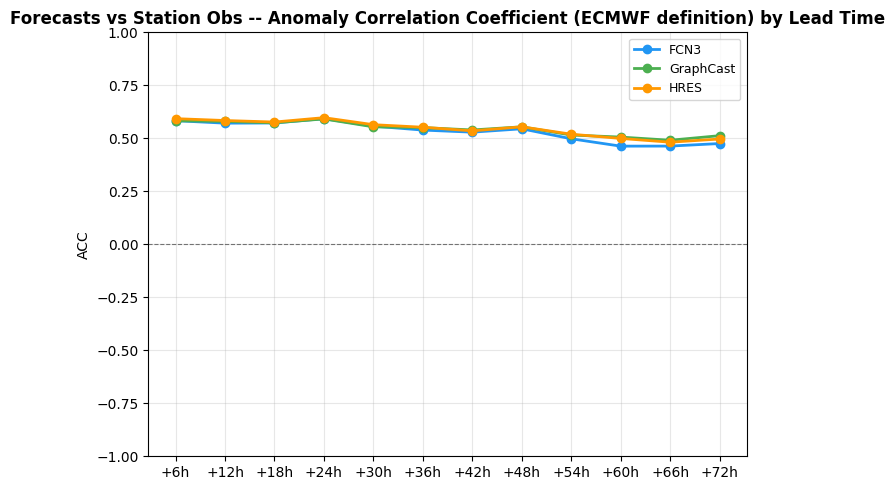

In [22]:
# 16.2 Figure: ACC vs lead time (Forecasts vs Station Obs)
fig, ax = plt.subplots(figsize=(7, 5))
for model in MODEL_ORDER:
    sub = acc_vs_obs[acc_vs_obs['model'] == model].set_index('lead_h').reindex(LEAD_HOURS)
    ax.plot(LEAD_HOURS, sub['ACC'], marker='o', ms=6, lw=2, color=CLR[model], label=model)
ax.axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
ax.set_xticks(LEAD_HOURS); ax.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS])
ax.set_ylim(-1, 1)
ax.set_ylabel('ACC', fontsize=10)
ax.set_title('Forecasts vs Station Obs -- Anomaly Correlation Coefficient (ECMWF definition) by Lead Time', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'acc_vs_obs_lead_time.png', dpi=130, bbox_inches='tight')
plt.show()

In [23]:
# 16.3 Model ranking by ACC vs Station Obs (mean across lead times)
acc_obs_pivot = (acc_vs_obs.pivot(index='model', columns='lead_h', values='ACC')
                  .reindex(MODEL_ORDER))
acc_obs_pivot.columns = [f'+{lh}h' for lh in acc_obs_pivot.columns]
acc_obs_pivot['Mean ACC'] = acc_obs_pivot.mean(axis=1)
acc_obs_pivot['Rank'] = acc_obs_pivot['Mean ACC'].rank(ascending=False).astype(int)
acc_obs_pivot = acc_obs_pivot.sort_values('Rank')
print('Model ranking by ACC vs Station Obs (higher is better)')
display(acc_obs_pivot.round(3))

Model ranking by ACC vs Station Obs (higher is better)


,+6h,+12h,+18h,+24h,+30h,+36h,+42h,+48h,+54h,+60h,+66h,+72h,Mean ACC,Rank
model,,,,,,,,,,,,,,
HRES,0.593,0.584,0.577,0.597,0.564,0.552,0.535,0.554,0.519,0.499,0.482,0.497,0.546,1
GraphCast,0.583,0.580,0.573,0.591,0.554,0.551,0.539,0.554,0.515,0.506,0.491,0.512,0.546,2
FCN3,0.583,0.572,0.572,0.593,0.557,0.539,0.529,0.545,0.498,0.463,0.463,0.475,0.532,3


ACC vs Station Obs, station x model (mean over all lead times)


model,FCN3,GraphCast,HRES
station,,,
SN88690,0.426,0.415,0.465
SN90490,0.338,0.341,0.291
SN90760,0.336,0.268,0.321
SN90800,0.639,0.695,0.606
SN90720,0.655,0.639,0.686
SN91740,0.286,0.296,0.334
SN89350,0.488,0.545,0.517
SN87110,0.715,0.770,0.758
SN85380,0.639,0.631,0.635


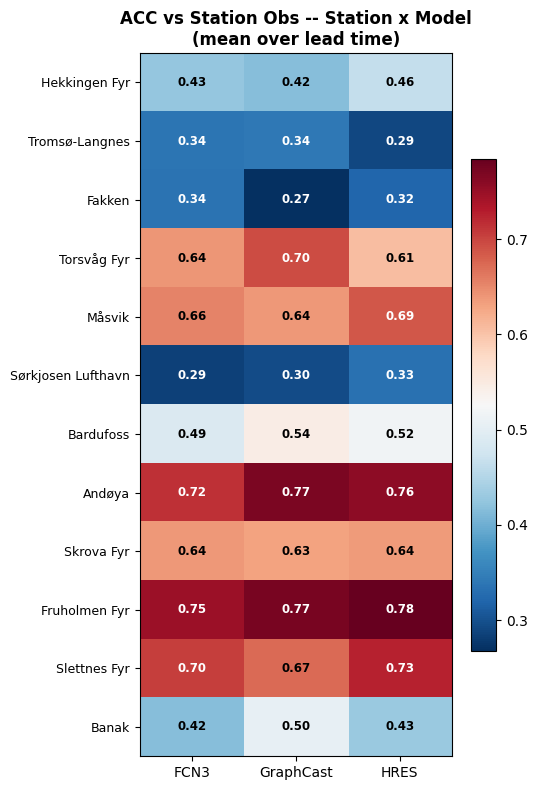

In [24]:
# 16.3b Station-level breakdown: ACC vs Station Obs, station x model (mean over lead
# time), same heatmap convention as the RMSE/nRMSE/Bias/nBias station x model heatmaps
# above (Section 8) -- lets a reviewer see whether ACC skill is uniform across stations
# or concentrated at a few (same question as the RMSE station heatmap, for this metric).
acc_station_model_obs = (acc_by_station.groupby(['station', 'model'])['ACC'].mean())

print('ACC vs Station Obs, station x model (mean over all lead times)')
display(acc_station_model_obs.unstack('model').reindex(STATION_ORDER).round(3))

fig, ax = plt.subplots(figsize=(5.5, 8))
pivot = acc_station_model_obs.unstack('model').reindex(STATION_ORDER).reindex(columns=MODEL_ORDER)
mat = pivot.values.astype(float)
vmin, vmax = np.nanmin(mat), np.nanmax(mat)
im = ax.imshow(mat, cmap='RdBu_r', aspect='auto', vmin=vmin, vmax=vmax)
ax.set_xticks(range(len(MODEL_ORDER))); ax.set_xticklabels(MODEL_ORDER, fontsize=10)
ax.set_yticks(range(len(STATION_ORDER))); ax.set_yticklabels(STATION_LABELS, fontsize=9)
ax.set_title('ACC vs Station Obs -- Station x Model\n(mean over lead time)', fontsize=12, fontweight='bold')
mid = (vmin + vmax) / 2
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat[i, j]
        if not np.isnan(v):
            clr = 'white' if abs(v - mid) > (vmax - vmin) * 0.3 else 'black'
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8.5, color=clr, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.7, pad=0.05)
plt.tight_layout()
plt.savefig(FIG_DIR / 'acc_vs_obs_station_model_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

In [25]:
# 16.4 ACC vs ERA5, using the official WeatherBench2 ERA5 climatology (10m_wind_speed,
# 1990-2017 baseline, day-of-year x 6h, WB2's own 61-day linear-window smoothing) instead
# of the station-derived one above. Extracted once from the login node -- the compute
# nodes used to run this notebook cannot reach GCS (verified directly: the request hangs
# rather than erroring) -- via earth2studio.data.WB2Climatology's underlying zarr store
# (gs://weatherbench2/datasets/era5-hourly-climatology/1990-2017_6h_1440x721.zarr,
# WB2Climatology's actual __init__ default). The notebook only reads the small local CSV
# that one-time extraction produced; it never talks to GCS itself.
CSV_WB2_CLIMATOLOGY = OUT_ROOT / 'wb2_climatology_station_10m_wind_speed.csv'
wb2_climatology = pd.read_csv(CSV_WB2_CLIMATOLOGY)

acc_era5_df = master_df.dropna(subset=['forecast', 'era5']).copy()
acc_era5_df['hour'] = acc_era5_df['valid_time'].dt.hour
acc_era5_df['dayofyear'] = acc_era5_df['valid_time'].dt.dayofyear
acc_era5_df = acc_era5_df.merge(wb2_climatology, on=['station', 'hour', 'dayofyear'], how='left')
acc_era5_df['fcst_anom'] = acc_era5_df['forecast'] - acc_era5_df['climatology']
acc_era5_df['era5_anom'] = acc_era5_df['era5'] - acc_era5_df['climatology']

acc_by_station_era5 = compute_group_acc(acc_era5_df, ['model', 'station', 'lead_h'],
                                         fcst_col='fcst_anom', ref_col='era5_anom')
acc_vs_era5 = (acc_by_station_era5.groupby(['model', 'lead_h'])
               .agg(N=('N', 'sum'), ACC=('ACC', 'mean'), ACC_std=('ACC', 'std'))
               .reset_index())

acc_vs_era5 = acc_vs_era5.set_index(['model', 'lead_h']).reindex(
    pd.MultiIndex.from_product([MODEL_ORDER, LEAD_HOURS], names=['model', 'lead_h'])
).reset_index()

print('Anomaly Correlation Coefficient (ACC) vs ERA5 -- WeatherBench2 formula, '
      'WeatherBench2 official climatology (1990-2017); grouped by [model, lead_h]; '
      'ACC_std = spread across the 12 stations, not a CI')
display(acc_vs_era5.round(3))

Anomaly Correlation Coefficient (ACC) vs ERA5 -- WeatherBench2 formula, WeatherBench2 official climatology (1990-2017); grouped by [model, lead_h]; ACC_std = spread across the 12 stations, not a CI


,model,lead_h,N,ACC,ACC_std
0,FCN3,6,30684.0,0.945,0.042
1,FCN3,12,30684.0,0.917,0.041
2,FCN3,18,30684.0,0.912,0.047
3,FCN3,24,30600.0,0.886,0.049
4,FCN3,30,30600.0,0.882,0.038
5,FCN3,36,30600.0,0.856,0.039
6,FCN3,42,30600.0,0.846,0.040
7,FCN3,48,30516.0,0.811,0.045
8,FCN3,54,30516.0,0.792,0.034
9,FCN3,60,30516.0,0.750,0.038


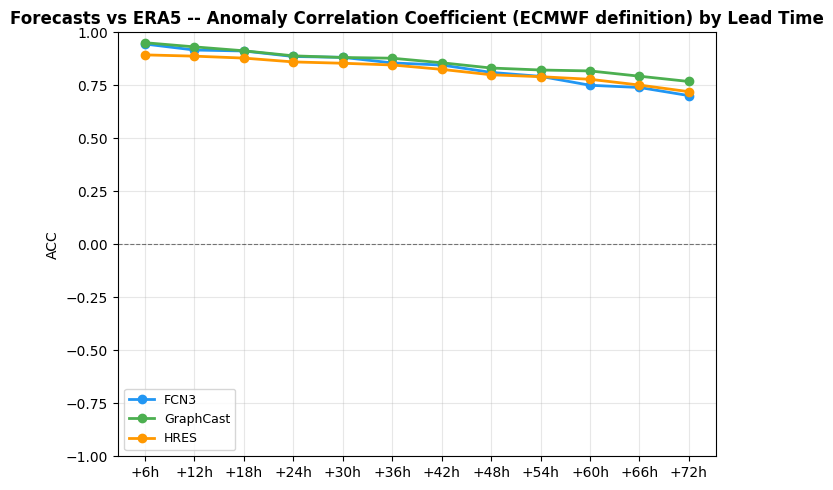

In [26]:
# 16.5 Figure: ACC vs lead time (Forecasts vs ERA5)
fig, ax = plt.subplots(figsize=(7, 5))
for model in MODEL_ORDER:
    sub = acc_vs_era5[acc_vs_era5['model'] == model].set_index('lead_h').reindex(LEAD_HOURS)
    ax.plot(LEAD_HOURS, sub['ACC'], marker='o', ms=6, lw=2, color=CLR[model], label=model)
ax.axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.5)
ax.set_xticks(LEAD_HOURS); ax.set_xticklabels([f'+{lh}h' for lh in LEAD_HOURS])
ax.set_ylim(-1, 1)
ax.set_ylabel('ACC', fontsize=10)
ax.set_title('Forecasts vs ERA5 -- Anomaly Correlation Coefficient (ECMWF definition) by Lead Time', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'acc_vs_era5_lead_time.png', dpi=130, bbox_inches='tight')
plt.show()

In [27]:
# 16.6 Model ranking by ACC vs ERA5 (mean across lead times)
acc_era5_pivot = (acc_vs_era5.pivot(index='model', columns='lead_h', values='ACC')
                   .reindex(MODEL_ORDER))
acc_era5_pivot.columns = [f'+{lh}h' for lh in acc_era5_pivot.columns]
acc_era5_pivot['Mean ACC'] = acc_era5_pivot.mean(axis=1)
acc_era5_pivot['Rank'] = acc_era5_pivot['Mean ACC'].rank(ascending=False).astype(int)
acc_era5_pivot = acc_era5_pivot.sort_values('Rank')
print('Model ranking by ACC vs ERA5 (higher is better)')
display(acc_era5_pivot.round(3))

Model ranking by ACC vs ERA5 (higher is better)


,+6h,+12h,+18h,+24h,+30h,+36h,+42h,+48h,+54h,+60h,+66h,+72h,Mean ACC,Rank
model,,,,,,,,,,,,,,
GraphCast,0.951,0.931,0.913,0.889,0.881,0.878,0.857,0.832,0.822,0.818,0.793,0.768,0.861,1
FCN3,0.945,0.917,0.912,0.886,0.882,0.856,0.846,0.811,0.792,0.750,0.740,0.701,0.836,2
HRES,0.894,0.888,0.878,0.860,0.854,0.846,0.825,0.800,0.791,0.778,0.751,0.720,0.824,3


ACC vs ERA5, station x model (mean over all lead times)


model,FCN3,GraphCast,HRES
station,,,
SN88690,0.857,0.873,0.856
SN90490,0.807,0.864,0.838
SN90760,0.850,0.815,0.843
SN90800,0.854,0.851,0.669
SN90720,0.853,0.874,0.860
SN91740,0.755,0.810,0.801
SN89350,0.763,0.802,0.740
SN87110,0.860,0.909,0.844
SN85380,0.872,0.904,0.839


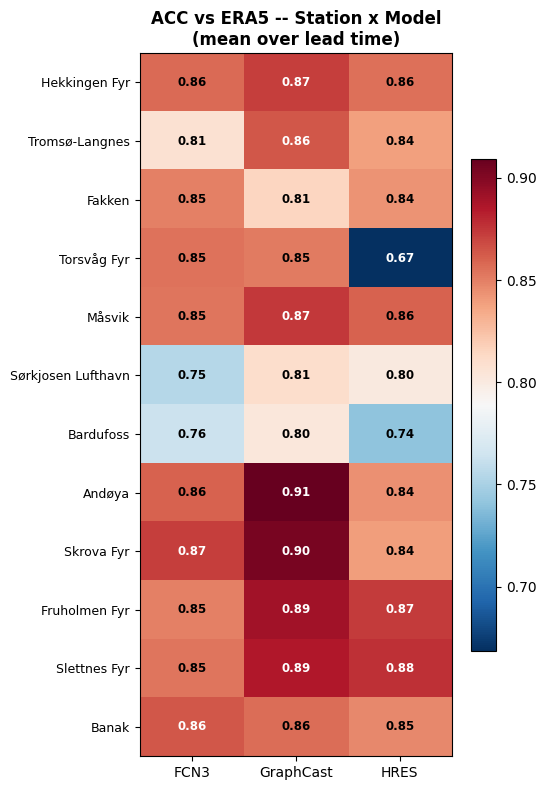

In [28]:
# 16.6b Station-level breakdown: ACC vs ERA5, station x model (mean over lead time),
# same convention as 16.3b above.
acc_station_model_era5 = (acc_by_station_era5.groupby(['station', 'model'])['ACC'].mean())

print('ACC vs ERA5, station x model (mean over all lead times)')
display(acc_station_model_era5.unstack('model').reindex(STATION_ORDER).round(3))

fig, ax = plt.subplots(figsize=(5.5, 8))
pivot = acc_station_model_era5.unstack('model').reindex(STATION_ORDER).reindex(columns=MODEL_ORDER)
mat = pivot.values.astype(float)
vmin, vmax = np.nanmin(mat), np.nanmax(mat)
im = ax.imshow(mat, cmap='RdBu_r', aspect='auto', vmin=vmin, vmax=vmax)
ax.set_xticks(range(len(MODEL_ORDER))); ax.set_xticklabels(MODEL_ORDER, fontsize=10)
ax.set_yticks(range(len(STATION_ORDER))); ax.set_yticklabels(STATION_LABELS, fontsize=9)
ax.set_title('ACC vs ERA5 -- Station x Model\n(mean over lead time)', fontsize=12, fontweight='bold')
mid = (vmin + vmax) / 2
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat[i, j]
        if not np.isnan(v):
            clr = 'white' if abs(v - mid) > (vmax - vmin) * 0.3 else 'black'
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8.5, color=clr, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.7, pad=0.05)
plt.tight_layout()
plt.savefig(FIG_DIR / 'acc_vs_era5_station_model_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

### 16.7 Overall ACC per model (single number, for the headline comparison)

Averaging over lead time in addition to station is the same equal-weighting principle used
throughout this notebook for stations (see `compute_group_metrics_by_station`): each
(station, lead_h) cell is weighted equally regardless of its sample count, rather than pooling
every anomaly pair across stations and lead times into one giant correlation. Pooling like that
would let *between*-station or *between*-lead-time differences (different climatological
residual levels, different systematic error growth) leak into the correlation, instead of
measuring only the *within*-group anomaly tracking the ECMWF definition intends. So the overall
number below is the plain mean of the 12 stations x 12 lead times = 144 already-computed
per-group ACC values (`acc_by_station` / `acc_by_station_era5`), not a re-pooled correlation.

In [29]:
# 16.7 Overall ACC per model: equal-weighted mean over the full (station, lead_h) grid --
# not a re-pooled correlation over all anomaly pairs (see markdown above for why).
overall_acc_obs = acc_by_station.groupby('model')['ACC'].mean()
overall_acc_era5 = acc_by_station_era5.groupby('model')['ACC'].mean()

overall_acc = pd.DataFrame({
    'ACC vs Obs': overall_acc_obs,
    'ACC vs ERA5': overall_acc_era5,
}).reindex(MODEL_ORDER)
overall_acc['Rank vs Obs'] = overall_acc['ACC vs Obs'].rank(ascending=False).astype(int)
overall_acc['Rank vs ERA5'] = overall_acc['ACC vs ERA5'].rank(ascending=False).astype(int)
overall_acc = overall_acc[['ACC vs Obs', 'Rank vs Obs', 'ACC vs ERA5', 'Rank vs ERA5']]

print('Overall ACC per model (equal-weighted mean over 12 stations x 12 lead times)')
display(overall_acc.round(3))

Overall ACC per model (equal-weighted mean over 12 stations x 12 lead times)


,ACC vs Obs,Rank vs Obs,ACC vs ERA5,Rank vs ERA5
model,,,,
FCN3,0.532,3,0.836,2
GraphCast,0.546,2,0.861,1
HRES,0.546,1,0.824,3


## 18. Computational Performance: Training Cost (Literature) and Inference Cost (Measured)

Addresses the reviewer request for a complete computational-cost analysis of FCN3, GraphCast,
and HRES, covering both training and inference. Since FCN3 and GraphCast are used here as
**pretrained** weights (never trained by us), their training cost is cited from the original
papers, not measured. Inference cost, by contrast, is measured directly from our own production
SLURM job logs (`experiments/jobs/logs/nldl/case_study_{fcn3,gc}_72h_interp_*.out`, job IDs
1594527 and 1594534 -- the exact runs that produced the master forecast dataset every other
analysis in this notebook depends on), not estimated.

**Training cost** (from the literature -- not applicable to HRES, which is a physics-based NWP
model, not trained):

| Model | Stage | Hardware | Time | Compute |
|---|---|---|---|---|
| FCN3 ([Bonev et al. 2025](https://arxiv.org/abs/2507.12144)) | Pre-training 1 | 1024x H100 | 78h | 79,872 H100-h |
| | Pre-training 2 | 512x A100 | 15h | 7,680 A100-h |
| | Fine-tuning | 256x H100 | 8h | 2,048 H100-h |
| GraphCast ([Lam et al. 2023, *Science*](https://arxiv.org/abs/2212.12794)) | Single stage | 32x TPU v4 | ~4 weeks | ~21,504 TPU-v4-h (~2.5 accelerator-years) |
| HRES | -- | N/A, physics-based | -- | -- |

**Inference cost** (measured on our cluster -- 1x NVIDIA H200 GPU (141GB), 4 CPU cores per job,
Olivia "accel" partition): computed below directly from the per-initialization timestamps
`earth2studio.run.deterministic` prints to each job's log (one "Inference device: cuda" line per
forecast), across all 7 case-study years (2016-2022) for both models, so this is a measured
distribution, not a single-run estimate.


In [ ]:
# 18.1 Per-initialization and per-step inference wall-clock, parsed directly from the
# production job logs (one measurement per year, 2016-2022, 365-366 daily initializations
# each -- 2557 total per model). The first inference call in each log is dropped from the
# steady-state stats (it includes one-time model/weight loading, not representative of
# per-forecast cost).
import re
import glob
from datetime import datetime

LOG_DIR = Path('/cluster/home/siyan/github/WF-experiments/experiments/jobs/logs/nldl')
N_LEAD_STEPS = 12  # +6h ... +72h

def per_init_deltas(path):
    times = []
    with open(path, errors='ignore') as f:
        for line in f:
            m = re.search(r'(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})\.\d+.*Inference device: cuda', line)
            if m:
                times.append(datetime.strptime(m.group(1), '%Y-%m-%d %H:%M:%S'))
    deltas = np.array([(times[i + 1] - times[i]).total_seconds() for i in range(len(times) - 1)])
    return len(times), deltas[1:] if len(deltas) > 1 else deltas  # drop first (cold start)

rows = []
for model, pattern in [
    ('FCN3', str(LOG_DIR / 'case_study_fcn3_72h_interp_1594527_*.out')),
    ('GraphCast', str(LOG_DIR / 'case_study_gc_72h_interp_1594534_*.out')),
]:
    for log_path in sorted(glob.glob(pattern)):
        n_inits, steady = per_init_deltas(log_path)
        rows.append({'model': model, 'log': Path(log_path).name, 'n_inits': n_inits,
                     'mean_per_init_s': steady.mean(), 'std_per_init_s': steady.std()})

per_year_timing = pd.DataFrame(rows)
print('Per-year inference timing (one production job per year, 2016-2022):')
display(per_year_timing.round(2))

timing_summary = per_year_timing.groupby('model').agg(
    n_years=('log', 'count'), total_inits=('n_inits', 'sum'),
    mean_per_init_s=('mean_per_init_s', 'mean'), std_across_years_s=('mean_per_init_s', 'std'))
timing_summary['mean_per_step_s'] = timing_summary['mean_per_init_s'] / N_LEAD_STEPS
print(f'\nSummary across all {timing_summary["n_years"].iloc[0]} years '
      f'({timing_summary["total_inits"].sum():,} total forecast initializations):')
display(timing_summary.round(3))


In [ ]:
# 18.2 Memory footprint and hardware, from `seff`/`sacct` job accounting (host RAM peak
# usage across all 7 years) and the vendor-documented minimum GPU memory requirement for
# each model (earth2studio model card "Badges" metadata -- see earth2studio/models/px/fcn3.py
# and graphcast_operational.py). GPU VRAM is not tracked by this cluster's Slurm accounting
# plugin, so the vendor-documented minimum is reported instead of a measured peak.
memory_hardware = pd.DataFrame([
    {'model': 'FCN3', 'host_RAM_GB_range': '65-68', 'gpu_mem_min_GB': 80,
     'gpu_used': 'NVIDIA H200 (141GB)', 'cpu_cores': 4},
    {'model': 'GraphCast', 'host_RAM_GB_range': '57-61', 'gpu_mem_min_GB': 40,
     'gpu_used': 'NVIDIA H200 (141GB)', 'cpu_cores': 4},
])
print('Memory footprint and hardware (measured host RAM; vendor-documented GPU memory floor)')
display(memory_hardware)

print('\nHRES (external reference, not run locally -- WeatherBench2 archive used directly):')
print('ECMWF IFS operational: 11,664-core CPU cluster, ~1 hour for a 10-day forecast '
      '(figure as cited in Lam et al. 2023, Science, the GraphCast paper).')
